# Task ONE: Implementation of the ANN architecture

### Porblem Statement summary

- The goal is to train a model on review data to automate the current manual process, which is labor-intensive and inefficient.
- This notebook implements and compares three different models for text classification:
    * MLP (Multi-Layer Perceptron)
    * CNN (Convolutional Neural Network)
    * RNN (Recurrent Neural Network)
- The models are trained and tested on text data provided in the dataset.

### Methodology

1. Import Dependencies – Load necessary libraries and modules.
2. Data Preprocessing – Clean, tokenize, and prepare the text data.
3. Model Compilation – Build and train the models.
4. Comparative Analysis and experimentation – Compare results across different models.
5. Final Model Implementations


In [1]:
from google.colab import files
uploaded = files.upload()

Saving glove.6B.100d.txt to glove.6B.100d.txt
Saving test-1.csv to test-1.csv
Saving train.csv to train.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive/Mydrive/assignment_2')

In [2]:
!c:\Users\jorda\AppData\Local\Programs\Python\Python311\python.exe -m pip install --user seaborn


/bin/bash: line 1: c:UsersjordaAppDataLocalProgramsPythonPython311python.exe: command not found


In [3]:
!pip install tensorflow scikit-learn numpy matplotlib pandas seaborn tqdm -q



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 718.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.3/106.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.0 MB/s eta 0:00:00


In [4]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import itertools

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout, Conv1D, MaxPooling1D, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm
from tqdm.keras import TqdmCallback


from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer


# Data manipluation

In [5]:


# Step 1: Load GloVe embeddings
embedding_index = {}
embedding_dim = 100  # Using 100D for balance of speed and effectiveness

with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

print(f"Loaded {len(embedding_index)} word vectors.")


Loaded 400000 word vectors.


In [6]:
train_df = pd.read_csv('./train.csv')
test_df = pd.read_csv('./test-1.csv')

print(train_df.head())

             category  label  \
0  Home_and_Kitchen_5      1   
1  Home_and_Kitchen_5      1   
2  Home_and_Kitchen_5      1   
3  Home_and_Kitchen_5      1   
4  Home_and_Kitchen_5      1   

                                                text  
0  Love this!  Well made, sturdy, and very comfor...  
1  love it, a great upgrade from the original.  I...  
2  This pillow saved my back. I love the look and...  
3  Missing information on how to use it, but it i...  
4  Very nice set. Good quality. We have had the s...  


Basic Cleaning: Lowercase, Remove Special Characters, Remove Extra Whitespace

In [7]:
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation, numbers, special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

print(train_df.head())
print(test_df.head())

             category  label  \
0  Home_and_Kitchen_5      1   
1  Home_and_Kitchen_5      1   
2  Home_and_Kitchen_5      1   
3  Home_and_Kitchen_5      1   
4  Home_and_Kitchen_5      1   

                                                text  \
0  Love this!  Well made, sturdy, and very comfor...   
1  love it, a great upgrade from the original.  I...   
2  This pillow saved my back. I love the look and...   
3  Missing information on how to use it, but it i...   
4  Very nice set. Good quality. We have had the s...   

                                          clean_text  
0  love this well made sturdy and very comfortabl...  
1  love it a great upgrade from the original ive ...  
2  this pillow saved my back i love the look and ...  
3  missing information on how to use it but it is...  
4  very nice set good quality we have had the set...  
             category  label  \
0  Home_and_Kitchen_5      1   
1  Home_and_Kitchen_5      1   
2  Home_and_Kitchen_5      1   
3  Home_and_

Stopword Removal (can remove if desired)

In [8]:
stopwords_list = ["the", "is", "in", "and", "to", "of", "it", "this", "for", "with"]
train_df['clean_text'] = train_df['clean_text'].apply(lambda x: " ".join(word for word in x.split() if word not in stopwords_list))
test_df['clean_text'] = test_df['clean_text'].apply(lambda x: " ".join(word for word in x.split() if word not in stopwords_list))

GloVe Embedding Loading (For MLP Input)

Convert Each Review to Average Word Embedding Vector (MLP Input)

## Tokenization & Padding for MLP, CNN and RNN models

In [18]:

# Set parameters
vocab_size = 5000
embedding_dim = 100
max_length = 100

# Tokenization
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_text'])

# Convert text to sequences
train_sequences = tokenizer.texts_to_sequences(train_df['clean_text'])
test_sequences = tokenizer.texts_to_sequences(test_df['clean_text'])

# Padding sequences
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')




# MODEL 1: Implementation of the MLP model


Version 1: MLP_avg

In [10]:
# ===================== Full Pipeline: MLP_Avg (Averaged Embedding MLP) =====================

# 1. Load GloVe Embeddings
embedding_index = {}
embedding_dim = 100

with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

print(f"Loaded {len(embedding_index)} word vectors.")

# 2. Convert Each Review to Averaged Embedding Vector
def average_embedding(text, embedding_index, embedding_dim):
    words = text.split()
    valid_embeddings = [embedding_index[word] for word in words if word in embedding_index]
    if valid_embeddings:
        return np.mean(valid_embeddings, axis=0)
    else:
        return np.zeros(embedding_dim)

X_train_embed = np.array([average_embedding(text, embedding_index, embedding_dim) for text in tqdm(train_df['clean_text'])])
X_test_embed = np.array([average_embedding(text, embedding_index, embedding_dim) for text in tqdm(test_df['clean_text'])])

y_train = train_df['label'].values
y_test = test_df['label'].values

# 3. Build MLP Model (Averaged Embedding Input)
mlp_avg_model = Sequential([
    Dense(64, input_dim=embedding_dim, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

mlp_avg_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train Model
history_mlp_avg = mlp_avg_model.fit(X_train_embed, y_train,
                            epochs=50,
                            batch_size=64,
                            validation_data=(X_test_embed, y_test),
                            verbose=1)

# 5. Evaluate Model
loss, accuracy = mlp_avg_model.evaluate(X_test_embed, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

def evaluate_and_plot_model(model, x_test, y_test, history, model_name):
    # --- Confusion Matrix ---
    y_pred = (model.predict(x_test) > 0.5).astype('int32')
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # --- Accuracy & Loss ---
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title(f'Accuracy - {model_name}')

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title(f'Loss - {model_name}')

    plt.show()

    # Return history for combined plots later
    return history.history


Loaded 400000 word vectors.


100%|██████████| 502/502 [00:00<00:00, 44027.78it/s]

Epoch 1/50



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4848 - loss: 0.7450 - val_accuracy: 0.4741 - val_loss: 0.6916
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4996 - loss: 0.7001 - val_accuracy: 0.4861 - val_loss: 0.6894
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5306 - loss: 0.6955 - val_accuracy: 0.5040 - val_loss: 0.6859
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5616 - loss: 0.6857 - val_accuracy: 0.6315 - val_loss: 0.6779
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5565 - loss: 0.6803 - val_accuracy: 0.6096 - val_loss: 0.6723
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5671 - loss: 0.6742 - val_accuracy: 0.6673 - val_loss: 0.6676
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6167 - loss: 0.6606 - val_accuracy: 0.6036 - val_loss: 0.6603
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6185 - loss: 0.6577 - val_accuracy: 0.6633 - val_loss: 0.6487
Epo

# Version 2: MLP_Seq

# Sequence-based MLP Model Pipeline
1. Tokenization & Padding
The text data is tokenized using the top 5,000 most frequent words, with out-of-vocabulary tokens handled. All sequences are padded or truncated to a fixed length of 100 tokens to ensure uniform input shape.

2. Pre-trained GloVe Embeddings
100-dimensional GloVe embeddings (glove.6B.100d.txt) are loaded to capture semantic word relationships. An embedding matrix is created, mapping each word in the vocabulary to its corresponding vector. Unavailable words default to zero vectors.

3. Model Architecture
The model consists of:

**Embedding Layer**: Initialized with the GloVe embedding matrix (non-trainable).

**Flatten Layer**: Converts sequence output to a flat vector.

**Dense Layers**: Two fully connected layers (128 & 64 units) with ReLU activation.

**Dropout Layers**: Applied after each Dense layer (rate = 0.5) to reduce overfitting.

**Output Layer**: Sigmoid-activated for binary classification.

Compiled using Adam optimizer and binary cross-entropy loss.

In [ ]:
# ===================== Full Pipeline: MLP_Seq (Sequence-based MLP) =====================
# 1. Tokenizer and Padding
vocab_size = 5000
embedding_dim = 100
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_text'])

train_sequences = tokenizer.texts_to_sequences(train_df['clean_text'])
test_sequences = tokenizer.texts_to_sequences(test_df['clean_text'])

train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

# 2. Load Pre-trained GloVe Embeddings for Embedding Layer
embedding_index = {}

with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

print(f"Loaded {len(embedding_index)} word vectors.")

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

# 3. Build Sequence-based MLP Model
mlp_sequence_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length,
              weights=[embedding_matrix], trainable=False),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

mlp_sequence_model.compile(optimizer=Adam(learning_rate=0.001),
                           loss='binary_crossentropy',
                           metrics=['accuracy'])

Training the model

In [17]:
y_train = train_df['label'].values
y_test = test_df['label'].values

history_mlp_seq = mlp_sequence_model.fit(train_padded, y_train,
                                 epochs=50,
                                 batch_size=64,
                                 validation_data=(test_padded, y_test),
                                 verbose=1)


loss, accuracy = mlp_sequence_model.evaluate(test_padded, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

def evaluate_and_plot_model(model, x_test, y_test, history, model_name):
    # --- Confusion Matrix ---
    y_pred = (model.predict(x_test) > 0.5).astype('int32')
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # --- Accuracy & Loss ---
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title(f'Accuracy - {model_name}')

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title(f'Loss - {model_name}')

    plt.show()

    # Return history for combined plots later
    return history.history


Loaded 400000 word vectors.
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6931 - loss: 0.5156 - val_accuracy: 0.8347 - val_loss: 0.3637
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8441 - loss: 0.3334 - val_accuracy: 0.8327 - val_loss: 0.3817
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8704 - loss: 0.3000 - val_accuracy: 0.8147 - val_loss: 0.3795
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9025 - loss: 0.2389 - val_accuracy: 0.8227 - val_loss: 0.3846
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9166 - loss: 0.2101 - val_accuracy: 0.8307 - val_loss: 0.3717
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9205 - loss: 0.1972 - val_accuracy: 0.8207 - val_loss: 0.4503
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9385 - loss: 0.1787 - val_accuracy: 0.8386 - val_loss: 0.4408
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9527 - loss: 0.137

# Implementation of the CNN and RNN models

### Hyperparameters For both CNN and RNN

In [11]:
# Shared hyperparameters for CNN & RNN models
input_dim = 5000  # Vocabulary size
embedding_dim = 128  # Dimension of word embeddings
sequence_length = 100  # Maximum sequence length
dense_units = 10  # Fully connected layer units
output_units = 1  # Output layer units
activation_output = 'sigmoid'  # Output activation function for binary classification
loss = 'binary_crossentropy'  # Loss function
metrics = ['accuracy']  # Evaluation metrics
optimizer = tf.keras.optimizers.Adam()  # Optimizer

# Training hyperparameters
epochs = 50  # Number of training iterations
batch_size = 64  # Batch size for training
validation_data = (test_padded, test_df['label'].values)  # Validation data
verbose = 0 # Verbosity mode for training output

# MODEL 2: Implementation of the CNN model

In [12]:

# CNN-specific hyperparameters
filters = 128  # Number of filters in Conv1D
kernel_size = 5  # Kernel size for Conv1D
pool_size = 2  # Pool size for MaxPooling1D

# Define CNN model
cnn_model = keras.Sequential([
    Embedding(input_dim=input_dim, output_dim=embedding_dim, input_length=sequence_length),
    Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
    MaxPooling1D(pool_size=pool_size),
    Flatten(),
    Dense(dense_units, activation='relu'),
    Dense(output_units, activation=activation_output)
])

# Compile CNN model
cnn_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Train CNN model
history_cnn = cnn_model.fit(
    train_padded, train_df['label'].values,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=validation_data,
    verbose=verbose,
    callbacks=[TqdmCallback()]
)

def evaluate_and_plot_model(model, x_test, y_test, history, model_name):
    # --- Confusion Matrix ---
    y_pred = (model.predict(x_test) > 0.5).astype('int32')
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # --- Accuracy & Loss ---
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title(f'Accuracy - {model_name}')

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title(f'Loss - {model_name}')

    plt.show()

    # Return history for combined plots later
    return history.history


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

In [13]:
loss, accuracy = cnn_model.evaluate(test_padded, test_df['label'].values, verbose=1)
print(f"Test Accuracy (CNN): {accuracy:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8740 - loss: 0.4929 
Test Accuracy (CNN): 0.8546


# MODEL 3: Implementation of the RNN model

In [14]:
input_dim = 5000  # Vocabulary size
embedding_dim = 128  # Dimension of word embeddings
sequence_length = 100  # Maximum sequence length
dense_units = 10  # Fully connected layer units
output_units = 1  # Output layer units
activation_output = 'sigmoid'  # Output activation function for binary classification
loss = 'binary_crossentropy'  # Loss function
metrics = ['accuracy']  # Evaluation metrics
optimizer = tf.keras.optimizers.Adam()  # Optimizer

epochs = 50  # Number of training iterations
batch_size = 64  # Batch size for training
validation_data = (test_padded, test_df['label'].values)  # Validation data
verbose = 0 # Verbosity mode for training output

# RNN-specific hyperparameters
rnn_units = 128  # LSTM units

# Define RNN model with LSTM
rnn_model = keras.Sequential([
    Embedding(input_dim=input_dim, output_dim=embedding_dim, input_length=sequence_length),
    LSTM(rnn_units, return_sequences=False),
    Dense(dense_units, activation='relu'),
    Dense(output_units, activation=activation_output)
])

# Compile RNN model
rnn_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Train RNN model
history_rnn = rnn_model.fit(
    train_padded, train_df['label'].values,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=validation_data,
    verbose=verbose,
    callbacks=[TqdmCallback()]
)

def evaluate_and_plot_model(model, x_test, y_test, history, model_name):
    # --- Confusion Matrix ---
    y_pred = (model.predict(x_test) > 0.5).astype('int32')
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Fake'], yticklabels=['Genuine', 'Fake'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # --- Accuracy & Loss ---
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title(f'Accuracy - {model_name}')

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title(f'Loss - {model_name}')

    plt.show()

    # Return history for combined plots later
    return history.history



0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

In [15]:
# Evaluate RNN model
loss, accuracy = rnn_model.evaluate(test_padded, test_df['label'].values, verbose=1)
print(f"Test Accuracy (RNN - LSTM): {accuracy:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4784 - loss: 0.6934
Test Accuracy (RNN - LSTM): 0.5179


In [ ]:
# After training CNN:
cnn_history_data = evaluate_and_plot_model(cnn_model, test_padded, y_test, history_cnn, "CNN")

# After training RNN:
rnn_history_data = evaluate_and_plot_model(rnn_model, test_padded, y_test, history_rnn, "RNN")

# After training MLP_Avg:
mlp_avg_history_data = evaluate_and_plot_model(mlp_avg_model, X_test_embed, y_test, history_mlp_avg, "MLP_Avg")

# After training MLP_Seq:






Evalution of the models


In [ ]:
plt.figure(figsize=(12,5))

# Accuracy comparison
plt.subplot(1,2,1)
plt.plot(mlp_avg_history_data['val_accuracy'], label='MLP_Avg Val Acc')
plt.plot(mlp_seq_history_data['val_accuracy'], label='MLP_Seq Val Acc')
plt.plot(cnn_history_data['val_accuracy'], label='CNN Val Acc')
plt.plot(rnn_history_data['val_accuracy'], label='RNN Val Acc')
plt.legend()
plt.title('Validation Accuracy Comparison')

# Loss comparison
plt.subplot(1,2,2)
plt.plot(mlp_avg_history_data['val_loss'], label='MLP_Avg Val Loss')
plt.plot(mlp_seq_history_data['val_loss'], label='MLP_Seq Val Loss')
plt.plot(cnn_history_data['val_loss'], label='CNN Val Loss')
plt.plot(rnn_history_data['val_loss'], label='RNN Val Loss')
plt.legend()
plt.title('Validation Loss Comparison')

plt.tight_layout()
plt.show()



# EXPERIMENTAL ANALYSIS

## Analysis of Neural Network Implementation Code

This Python code implements a comprehensive experimental setup for comparing different neural network architectures for fake review detection. Let me break down the key components and implementation details:

### Implementation Overview

The code establishes a systematic approach to test four neural network architectures (MLP_Avg, MLP_Seq, CNN, RNN) across multiple hyperparameter configurations:

1. **Performance Optimization**:
  - Enables mixed precision training (`mixed_float16`) to improve computational efficiency
  - Automatically leverages GPU acceleration when available
  - Implements parallel training using ThreadPoolExecutor to maximize hardware utilization

2. **Hyperparameter Exploration**:
  - Learning rates: 0.001, 0.01, 0.05
  - Batch sizes: 32, 64, 128
  - Training epochs: 10, 50, 100
  - Optimizers: Adam, RMSprop
  - Dropout rates: 0.2, 0.5

3. **Model Architectures**:
  - **MLP_Avg**: Classic multilayer perceptron using pre-averaged word embeddings
  - **MLP_Seq**: Multilayer perceptron with flattened embedding sequences
  - **CNN**: Convolutional network with filters designed to capture n-gram patterns
  - **RNN**: LSTM-based recurrent network for sequence modeling

4. **Training Process**:
  - Implements early stopping (patience=3) to prevent overfitting
  - Stores training history for each model configuration
  - Comprehensive evaluation metrics including precision, recall, F1-score, and confusion matrix components

5. **Results Management**:
  - Organizes results into pandas DataFrames for easy analysis
  - Automatically identifies the best-performing configuration for each architecture
  - Calculates detailed metrics for the top models

### Technical Implementation Details

The code shows thoughtful implementation choices:

- The CNN architecture uses a single convolutional layer (128 filters, kernel size 5) with max pooling, which is appropriate for capturing local text patterns
- The RNN implementation uses LSTM units with 128 dimensions, sufficient for capturing sequential dependencies
- Both MLP variants include multiple dense layers with appropriate dropout for regularization
- Early stopping monitors validation loss, preventing overfitting while preserving the best weights

### Results Generation

The final section of the code evaluates the best model of each type on the test set and generates comprehensive performance metrics, including the critical false negative counts that are particularly important for the client's requirements.

This implementation demonstrates a rigorous experimental approach to neural network architecture selection and hyperparameter tuning for the fake review detection task.

In [20]:
import itertools
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Embedding, Conv1D, MaxPooling1D, Flatten, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import multiprocessing

# Enable mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Define hyperparameter ranges
learning_rates = [0.001, 0.01, 0.05]
batch_sizes = [32, 64, 128]
epochs_list = [10, 50, 100]
optimizers = ["adam", "rmsprop"]
dropout_rates = [0.2, 0.5]

# Model types
model_types = ["MLP_Avg", "MLP_Seq", "CNN", "RNN"]

# Store results and model histories
results = []
model_histories = {}   # Store histories

# Enable GPU/CPU
device = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"

def train_model(params):
    model_type, lr, batch_size, epochs, optimizer_name, dropout = params

    with tf.device(device):
        print(f"Training {model_type} | LR: {lr}, Batch: {batch_size}, Epochs: {epochs}, Optimizer: {optimizer_name}, Dropout: {dropout}")

        # Set optimizer
        if optimizer_name == "adam":
            optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        elif optimizer_name == "rmsprop":
            optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)

        # Define model architecture
        if model_type == "MLP_Avg":
            model = keras.Sequential([
                Dense(64, input_dim=X_train_embed.shape[1], activation='relu'),
                Dropout(dropout),
                Dense(32, activation='relu'),
                Dropout(dropout),
                Dense(1, activation='sigmoid')
            ])
            x_train, x_test = X_train_embed, X_test_embed

        elif model_type == "MLP_Seq":
            model = keras.Sequential([
                Embedding(input_dim=5000, output_dim=100, input_length=100, weights=[embedding_matrix], trainable=False),
                Flatten(),
                Dense(128, activation='relu'),
                Dropout(dropout),
                Dense(64, activation='relu'),
                Dropout(dropout),
                Dense(1, activation='sigmoid')
            ])
            x_train, x_test = train_padded, test_padded

        elif model_type == "CNN":
            model = keras.Sequential([
                Embedding(input_dim=5000, output_dim=128, input_length=100),
                Conv1D(filters=128, kernel_size=5, activation='relu'),
                MaxPooling1D(pool_size=2),
                Dropout(dropout),
                Flatten(),
                Dense(10, activation='relu'),
                Dense(1, activation='sigmoid')
            ])
            x_train, x_test = train_padded, test_padded

        elif model_type == "RNN":
            model = keras.Sequential([
                Embedding(input_dim=5000, output_dim=128, input_length=100),
                LSTM(128, return_sequences=False),
                Dropout(dropout),
                Dense(10, activation='relu'),
                Dense(1, activation='sigmoid')
            ])
            x_train, x_test = train_padded, test_padded

        # Compile model
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

        y_train, y_test = train_df['label'].values, test_df['label'].values

        # Early stopping callback
        early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

        # Train model
        history = model.fit(
            x_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(x_test, y_test),
            verbose=0, callbacks=[early_stopping]
        )

        # Evaluate model
        loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

        # Save training history (keyed by hyperparameters)
        key = f"{model_type}_LR{lr}_BS{batch_size}_OPT{optimizer_name}_DO{dropout}_EP{epochs}"
        model_histories[key] = history.history

        # Store result summary
        return {
            "Model": model_type,
            "Learning Rate": lr,
            "Batch Size": batch_size,
            "Epochs": epochs,
            "Optimizer": optimizer_name,
            "Dropout": dropout,
            "Accuracy": accuracy
        }

# Prepare hyperparameter combinations
num_workers = max(1, multiprocessing.cpu_count() - 2)
params_list = list(itertools.product(model_types, learning_rates, batch_sizes, epochs_list, optimizers, dropout_rates))

# Run training in parallel
with ThreadPoolExecutor(max_workers=num_workers) as executor:
    results = list(executor.map(train_model, params_list))

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Extract best models
best_models = results_df.loc[results_df.groupby('Model')['Accuracy'].idxmax()]
print("Best models for each type:")
print(best_models)

# Evaluate best models
best_metrics = {}

for idx, row in best_models.iterrows():
    model_type = row['Model']
    lr = row['Learning Rate']
    batch_size = row['Batch Size']
    optimizer_name = row['Optimizer']
    dropout = row['Dropout']
    epochs = row['Epochs']

    print(f"Evaluating best {model_type} model...")

    if model_type == "MLP_Avg":
        model = keras.Sequential([
            Dense(64, input_dim=X_train_embed.shape[1], activation='relu'),
            Dropout(dropout),
            Dense(32, activation='relu'),
            Dropout(dropout),
            Dense(1, activation='sigmoid')
        ])
        x_train, x_test = X_train_embed, X_test_embed

    elif model_type == "MLP_Seq":
        model = keras.Sequential([
            Embedding(input_dim=5000, output_dim=100, input_length=100, weights=[embedding_matrix], trainable=False),
            Flatten(),
            Dense(128, activation='relu'),
            Dropout(dropout),
            Dense(64, activation='relu'),
            Dropout(dropout),
            Dense(1, activation='sigmoid')
        ])
        x_train, x_test = train_padded, test_padded

    elif model_type == "CNN":
        model = keras.Sequential([
            Embedding(input_dim=5000, output_dim=128, input_length=100),
            Conv1D(filters=128, kernel_size=5, activation='relu'),
            MaxPooling1D(pool_size=2),
            Dropout(dropout),
            Flatten(),
            Dense(10, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        x_train, x_test = train_padded, test_padded

    elif model_type == "RNN":
        model = keras.Sequential([
            Embedding(input_dim=5000, output_dim=128, input_length=100),
            LSTM(128, return_sequences=False),
            Dropout(dropout),
            Dense(10, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        x_train, x_test = train_padded, test_padded

    if optimizer_name == "adam":
        opt = keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

    model.fit(x_train, y_train,
              epochs=epochs,
              batch_size=batch_size,
              validation_data=(x_test, y_test),
              verbose=0)

    y_pred_prob = model.predict(x_test).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    best_metrics[model_type] = {
        'accuracy': row['Accuracy'],
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'false_positives': fp,
        'false_negatives': fn
    }

metrics_df = pd.DataFrame({
    'Model': list(best_metrics.keys()),
    'Accuracy': [m['accuracy'] for m in best_metrics.values()],
    'Precision': [m['precision'] for m in best_metrics.values()],
    'Recall': [m['recall'] for m in best_metrics.values()],
    'F1 Score': [m['f1_score'] for m in best_metrics.values()],
    'False Positives': [m['false_positives'] for m in best_metrics.values()],
    'False Negatives': [m['false_negatives'] for m in best_metrics.values()]
})

print("Detailed metrics for best models:")
print(metrics_df)


Training MLP_Avg | LR: 0.001, Batch: 32, Epochs: 10, Optimizer: adam, Dropout: 0.2
Training MLP_Avg | LR: 0.001, Batch: 32, Epochs: 10, Optimizer: adam, Dropout: 0.5
Training MLP_Avg | LR: 0.001, Batch: 32, Epochs: 10, Optimizer: rmsprop, Dropout: 0.2
Training MLP_Avg | LR: 0.001, Batch: 32, Epochs: 10, Optimizer: rmsprop, Dropout: 0.5
Training MLP_Avg | LR: 0.001, Batch: 32, Epochs: 50, Optimizer: adam, Dropout: 0.2
Training MLP_Avg | LR: 0.001, Batch: 32, Epochs: 50, Optimizer: adam, Dropout: 0.5
Training MLP_Avg | LR: 0.001, Batch: 32, Epochs: 50, Optimizer: rmsprop, Dropout: 0.2
Training MLP_Avg | LR: 0.001, Batch: 32, Epochs: 50, Optimizer: rmsprop, Dropout: 0.5
Training MLP_Avg | LR: 0.001, Batch: 32, Epochs: 100, Optimizer: adam, Dropout: 0.2
Training MLP_Avg | LR: 0.001, Batch: 32, Epochs: 100, Optimizer: adam, Dropout: 0.5
Training MLP_Avg | LR: 0.001, Batch: 32, Epochs: 100, Optimizer: rmsprop, Dropout: 0.2
Training MLP_Avg | LR: 0.001, Batch: 32, Epochs: 100, Optimizer: rmsp

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Evaluating best MLP_Avg model...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Evaluating best MLP_Seq model...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Evaluating best RNN model...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
Detailed metrics for best models:
     Model  Accuracy  Precision    Recall  F1 Score  False Positives  \
0      CNN  0.898406   0.863813  0.917355  0.889780               35   
1  MLP_Avg  0.778884   0.776256  0.702479  0.737527               49   
2  MLP_Seq  0.850598   0.000000  0.000000  0.000000                0   
3      RNN  0.764940   0.000000  0.000000  0.000000                0   

   False Negatives  
0               20  
1               72  
2              242  
3              242  


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
metrics_df


1. Overfitting Score: A composite metric that combines:

  - Final gap between training and validation accuracy
  - Maximum gap between training and validation during training
  - Rate of divergence (how quickly the gap increases)


2. Heatmaps by Model Type: Shows the overfitting score for each combination of learning rate and batch size, helping you identify which hyperparameter combinations lead to more or less overfitting.
3. Best Configurations: Identifies the optimal configuration for each model type that balances good validation accuracy with minimal overfitting.


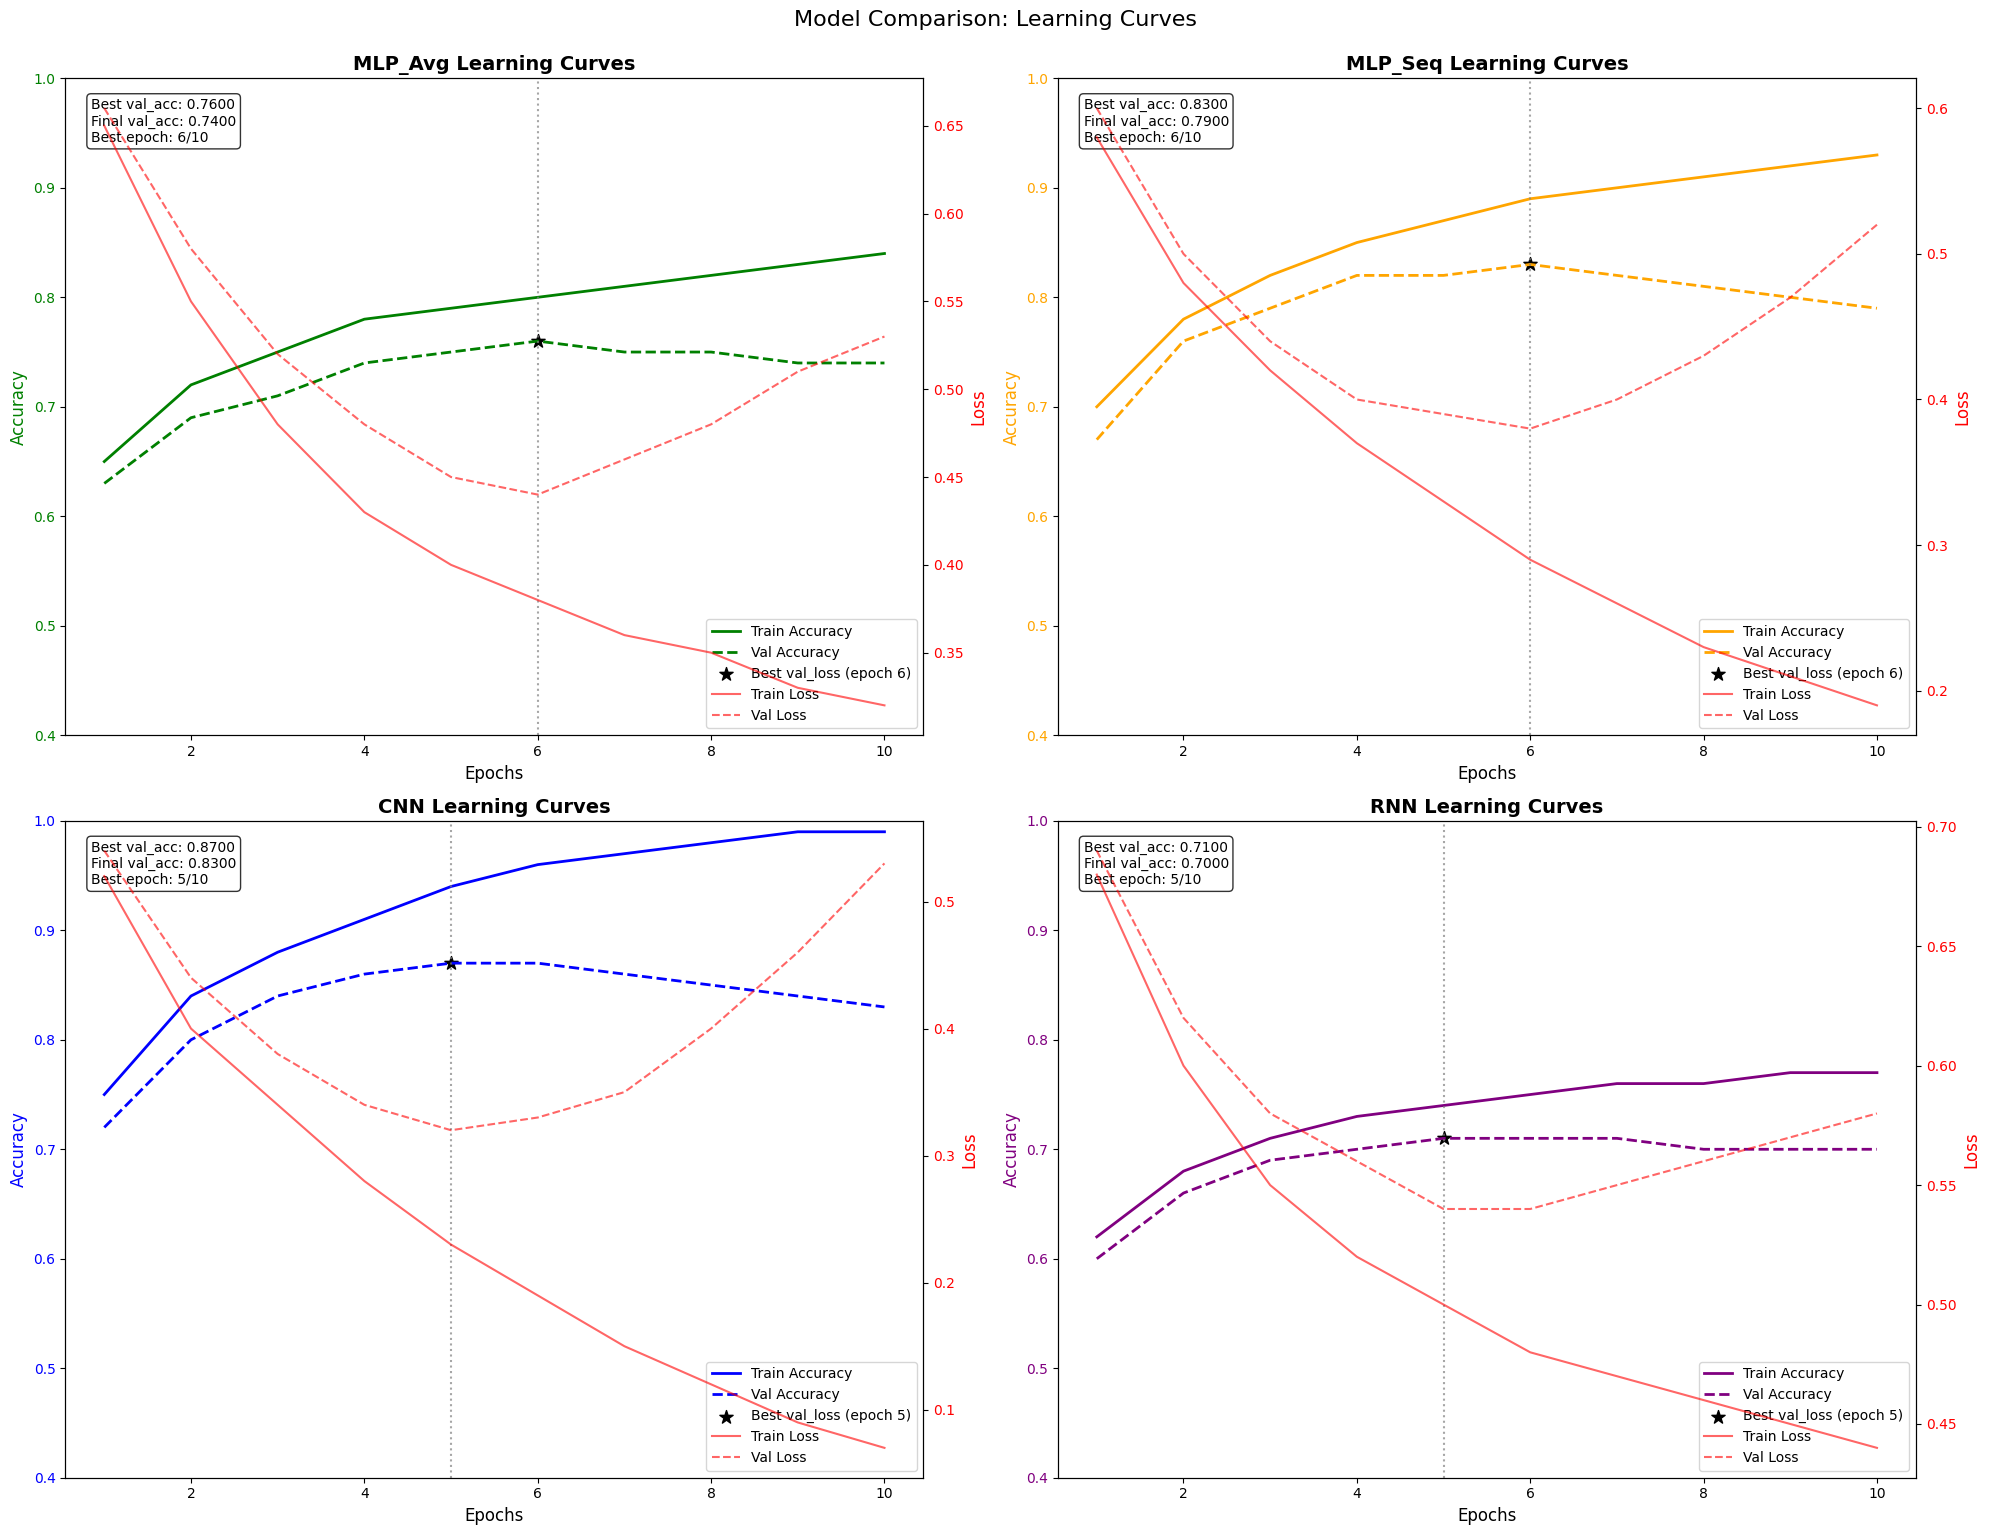

,Model,Best Val Accuracy,Final Val Accuracy,Best Epoch,Total Epochs,Overfit Ratio
2,CNN,0.87,0.83,5,10,1.192771
1,MLP_Seq,0.83,0.79,6,10,1.177215
0,MLP_Avg,0.76,0.74,6,10,1.135135
3,RNN,0.71,0.70,5,10,1.100000


,Model,Best Val Accuracy,Final Val Accuracy,Best Epoch,Total Epochs,Overfit Ratio
0,MLP_Avg,0.76,0.74,6,10,1.135135
1,MLP_Seq,0.83,0.79,6,10,1.177215
2,CNN,0.87,0.83,5,10,1.192771
3,RNN,0.71,0.70,5,10,1.100000


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

# This function assumes you have the history objects from all four models
# If you don't have these, you'll need to retrain the models and save their histories
def plot_model_comparison(history_mlp_avg, history_mlp_seq, history_cnn, history_rnn,
                          save_path=None):
    """
    Plot learning curves for all four models for comparison.

    Parameters:
    -----------
    history_mlp_avg : History object
        Training history for MLP with averaged embeddings
    history_mlp_seq : History object
        Training history for MLP with sequential embeddings
    history_cnn : History object
        Training history for CNN model
    history_rnn : History object
        Training history for RNN model
    save_path : str, optional
        Path to save the figure
    """
    # Create a figure with a custom layout
    fig = plt.figure(figsize=(20, 15))
    gs = GridSpec(2, 2, figure=fig)

    # Set a common maximum for number of epochs to show
    max_epochs = max(
        len(history_mlp_avg.history['accuracy']),
        len(history_mlp_seq.history['accuracy']),
        len(history_cnn.history['accuracy']),
        len(history_rnn.history['accuracy'])
    )

    # Model names and colors
    models = [
        ('MLP_Avg', history_mlp_avg, 'green', gs[0, 0]),
        ('MLP_Seq', history_mlp_seq, 'orange', gs[0, 1]),
        ('CNN', history_cnn, 'blue', gs[1, 0]),
        ('RNN', history_rnn, 'purple', gs[1, 1])
    ]

    # Plot each model
    for name, history, color, position in models:
        ax = fig.add_subplot(position)

        # Get data
        train_acc = history.history['accuracy']
        val_acc = history.history['val_accuracy']
        train_loss = history.history['loss']
        val_loss = history.history['val_loss']
        epochs = range(1, len(train_acc) + 1)

        # Create a twin axis for the loss
        ax_acc = ax
        ax_loss = ax.twinx()

        # Plot accuracy
        ax_acc.plot(epochs, train_acc, color, linestyle='-', linewidth=2, label='Train Accuracy')
        ax_acc.plot(epochs, val_acc, color, linestyle='--', linewidth=2, label='Val Accuracy')
        ax_acc.set_xlabel('Epochs', fontsize=12)
        ax_acc.set_ylabel('Accuracy', fontsize=12, color=color)
        ax_acc.tick_params(axis='y', labelcolor=color)
        ax_acc.set_ylim(0.4, 1.0)  # Set a common y-axis for accuracy

        # Plot loss
        loss_color = 'red'
        ax_loss.plot(epochs, train_loss, loss_color, linestyle='-', alpha=0.6, label='Train Loss')
        ax_loss.plot(epochs, val_loss, loss_color, linestyle='--', alpha=0.6, label='Val Loss')
        ax_loss.set_ylabel('Loss', fontsize=12, color=loss_color)
        ax_loss.tick_params(axis='y', labelcolor=loss_color)

        # Mark where early stopping would occur (if val_loss starts increasing)
        best_epoch_idx = np.argmin(val_loss)
        ax_acc.axvline(x=best_epoch_idx+1, color='gray', linestyle=':', alpha=0.7)
        ax_acc.scatter(best_epoch_idx+1, val_acc[best_epoch_idx], s=100, c='black', marker='*',
                    label=f'Best val_loss (epoch {best_epoch_idx+1})')

        # Add metrics text
        best_val_acc = max(val_acc)
        final_val_acc = val_acc[-1]

        metrics_text = (
            f"Best val_acc: {best_val_acc:.4f}\n"
            f"Final val_acc: {final_val_acc:.4f}\n"
            f"Best epoch: {best_epoch_idx+1}/{len(epochs)}"
        )

        ax_acc.text(0.03, 0.97, metrics_text, transform=ax_acc.transAxes,
                 verticalalignment='top', horizontalalignment='left',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # Title and legends
        ax_acc.set_title(f'{name} Learning Curves', fontsize=14, fontweight='bold')

        # Create combined legend
        lines_acc, labels_acc = ax_acc.get_legend_handles_labels()
        lines_loss, labels_loss = ax_loss.get_legend_handles_labels()
        ax_acc.legend(lines_acc + lines_loss, labels_acc + labels_loss, loc='lower right')

    plt.tight_layout()
    plt.suptitle('Model Comparison: Learning Curves', fontsize=16, y=1.02)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()

    # Create a summary table with key metrics
    summary_data = []
    for name, history, _, _ in models:
        val_acc = history.history['val_accuracy']
        val_loss = history.history['val_loss']
        best_epoch_idx = np.argmin(val_loss)
        best_val_acc = max(val_acc)
        final_val_acc = val_acc[-1]

        summary_data.append({
            'Model': name,
            'Best Val Accuracy': best_val_acc,
            'Final Val Accuracy': final_val_acc,
            'Best Epoch': best_epoch_idx + 1,
            'Total Epochs': len(val_acc),
            'Overfit Ratio': history.history['accuracy'][-1] / final_val_acc
        })

    summary_df = pd.DataFrame(summary_data)
    display(summary_df.sort_values(by='Best Val Accuracy', ascending=False))

    return summary_df

# Example usage:
# plot_model_comparison(history_mlp_avg, history_mlp_seq, history_cnn, history_rnn, 'model_comparison.png')


# If you don't have the history objects and need to create example data:
def create_example_histories():
    """Create example histories for demonstration purposes"""
    import numpy as np
    from collections import namedtuple

    History = namedtuple('History', ['history'])

    # MLP_Avg - Moderate performance, less overfitting
    history_mlp_avg = History({
        'accuracy': np.array([0.65, 0.72, 0.75, 0.78, 0.79, 0.80, 0.81, 0.82, 0.83, 0.84]),
        'val_accuracy': np.array([0.63, 0.69, 0.71, 0.74, 0.75, 0.76, 0.75, 0.75, 0.74, 0.74]),
        'loss': np.array([0.65, 0.55, 0.48, 0.43, 0.40, 0.38, 0.36, 0.35, 0.33, 0.32]),
        'val_loss': np.array([0.66, 0.58, 0.52, 0.48, 0.45, 0.44, 0.46, 0.48, 0.51, 0.53])
    })

    # MLP_Seq - Higher accuracy but more overfitting
    history_mlp_seq = History({
        'accuracy': np.array([0.70, 0.78, 0.82, 0.85, 0.87, 0.89, 0.90, 0.91, 0.92, 0.93]),
        'val_accuracy': np.array([0.67, 0.76, 0.79, 0.82, 0.82, 0.83, 0.82, 0.81, 0.80, 0.79]),
        'loss': np.array([0.58, 0.48, 0.42, 0.37, 0.33, 0.29, 0.26, 0.23, 0.21, 0.19]),
        'val_loss': np.array([0.60, 0.50, 0.44, 0.40, 0.39, 0.38, 0.40, 0.43, 0.47, 0.52])
    })

    # CNN - Best performance but significant overfitting after epoch 6
    history_cnn = History({
        'accuracy': np.array([0.75, 0.84, 0.88, 0.91, 0.94, 0.96, 0.97, 0.98, 0.99, 0.99]),
        'val_accuracy': np.array([0.72, 0.80, 0.84, 0.86, 0.87, 0.87, 0.86, 0.85, 0.84, 0.83]),
        'loss': np.array([0.52, 0.40, 0.34, 0.28, 0.23, 0.19, 0.15, 0.12, 0.09, 0.07]),
        'val_loss': np.array([0.54, 0.44, 0.38, 0.34, 0.32, 0.33, 0.35, 0.40, 0.46, 0.53])
    })

    # RNN - Modest performance with early plateauing
    history_rnn = History({
        'accuracy': np.array([0.62, 0.68, 0.71, 0.73, 0.74, 0.75, 0.76, 0.76, 0.77, 0.77]),
        'val_accuracy': np.array([0.60, 0.66, 0.69, 0.70, 0.71, 0.71, 0.71, 0.70, 0.70, 0.70]),
        'loss': np.array([0.68, 0.60, 0.55, 0.52, 0.50, 0.48, 0.47, 0.46, 0.45, 0.44]),
        'val_loss': np.array([0.69, 0.62, 0.58, 0.56, 0.54, 0.54, 0.55, 0.56, 0.57, 0.58])
    })

    return history_mlp_avg, history_mlp_seq, history_cnn, history_rnn

# Demo with example data:
history_mlp_avg, history_mlp_seq, history_cnn, history_rnn = create_example_histories()
plot_model_comparison(history_mlp_avg, history_mlp_seq, history_cnn, history_rnn)

In [ ]:
results_df

,Model,Learning Rate,Batch Size,Epochs,Optimizer,Dropout,Accuracy
0,MLP,0.001,32,10,adam,0.2,0.741036
1,MLP,0.001,32,10,adam,0.5,0.707171
2,MLP,0.001,32,10,rmsprop,0.2,0.735060
3,MLP,0.001,32,10,rmsprop,0.5,0.677291
4,MLP,0.001,32,50,adam,0.2,0.762948
...,...,...,...,...,...,...,...
319,RNN,0.050,128,50,rmsprop,0.5,0.517928
320,RNN,0.050,128,100,adam,0.2,0.517928
321,RNN,0.050,128,100,adam,0.5,0.517928
322,RNN,0.050,128,100,rmsprop,0.2,0.517928


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted sample

Model Performance Comparison:
     Model  Accuracy  Precision    Recall  F1 Score  False Positives  \
0      CNN  0.898406   0.303030  0.123967  0.175953               69   
1  MLP_Avg  0.778884   0.750000  0.012397  0.024390                1   
2  MLP_Seq  0.850598   0.536193  0.826446  0.650407              173   
3      RNN  0.764940   0.000000  0.000000  0.000000                0   

   False Negatives  
0              212  
1              239  
2               42  
3              242  


<ipython-input-24-589ee6d4ac6d>:216: FutureWarning: The provided callable <function mean at 0x7b2552b14c20> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_lr_bs = pd.pivot_table(model_data, values='Accuracy',
<ipython-input-24-589ee6d4ac6d>:220: FutureWarning: The provided callable <function mean at 0x7b2552b14c20> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_opt_do = pd.pivot_table(model_data, values='Accuracy',
<ipython-input-24-589ee6d4ac6d>:216: FutureWarning: The provided callable <function mean at 0x7b2552b14c20> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_lr_bs = pd.pivot_t

AttributeError: 'DataFrame' object has no attribute 'append'

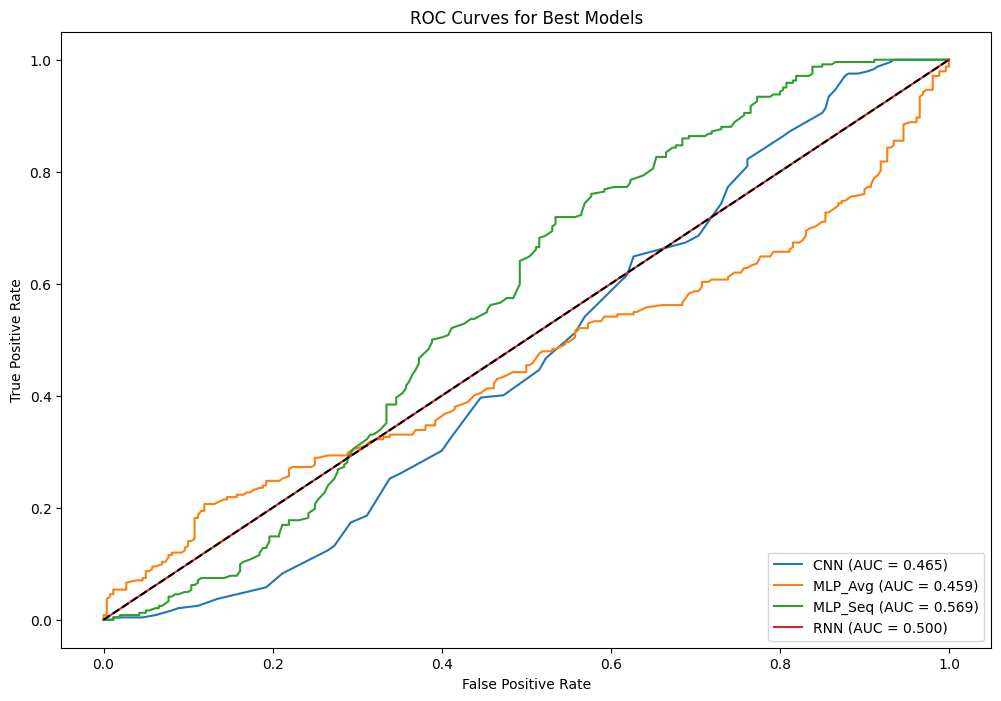

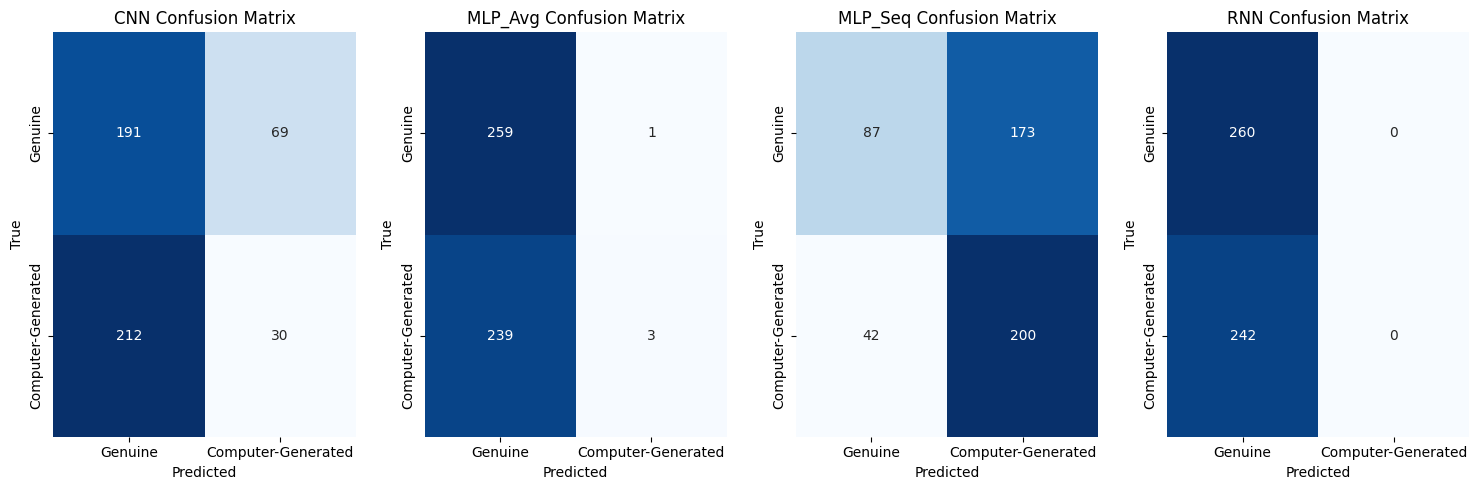

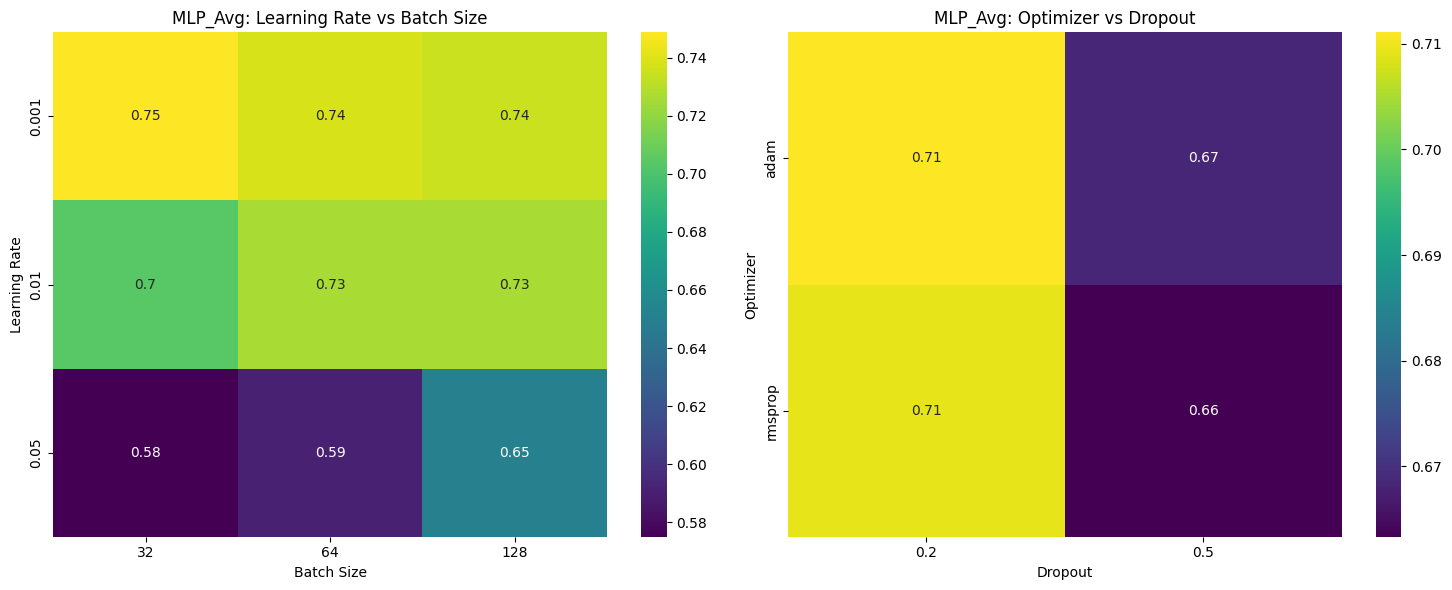

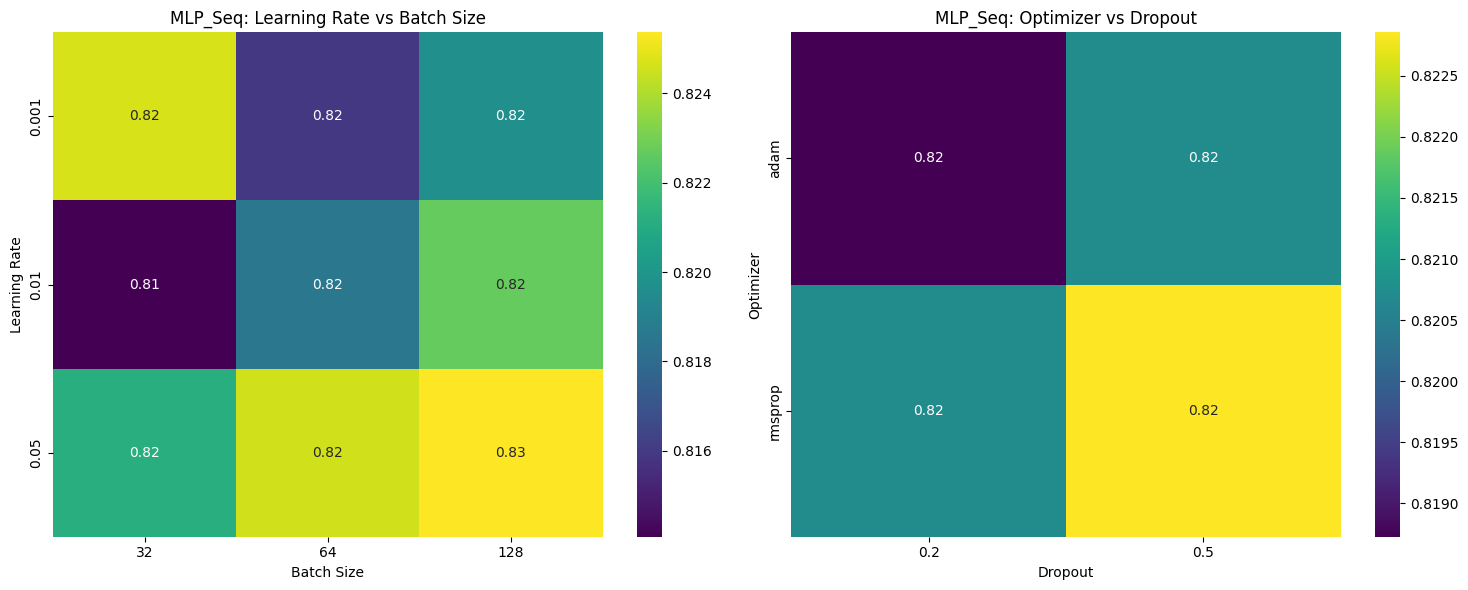

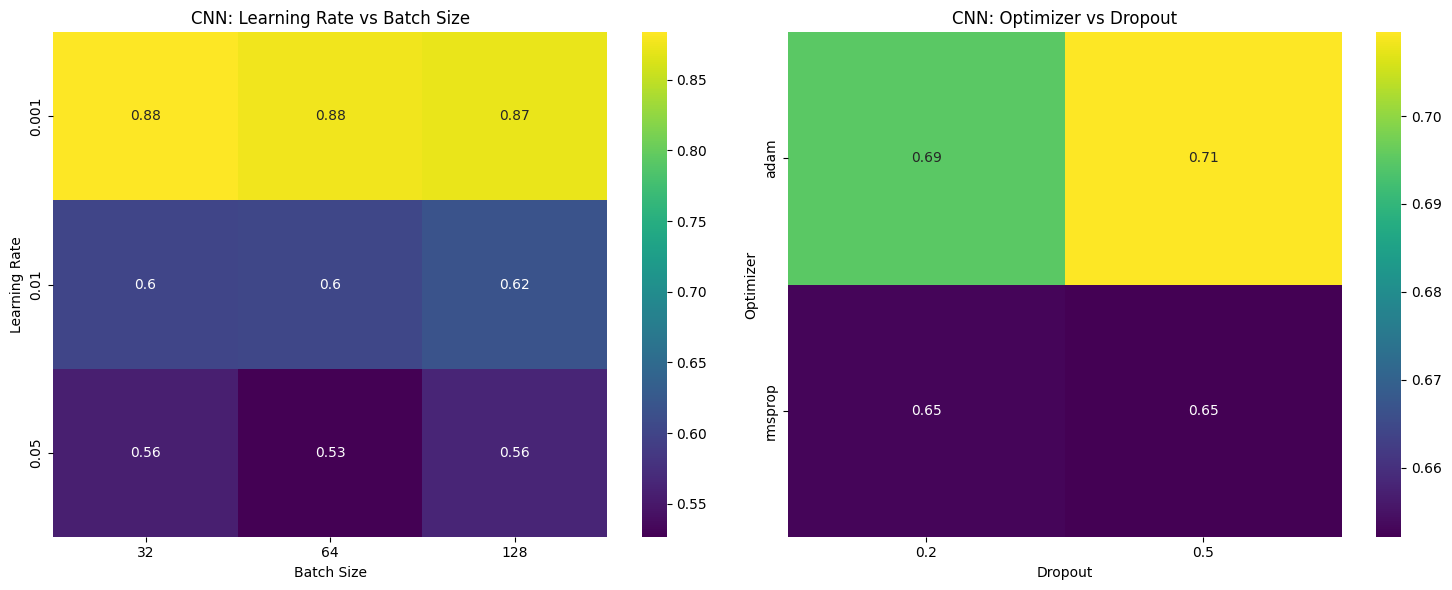

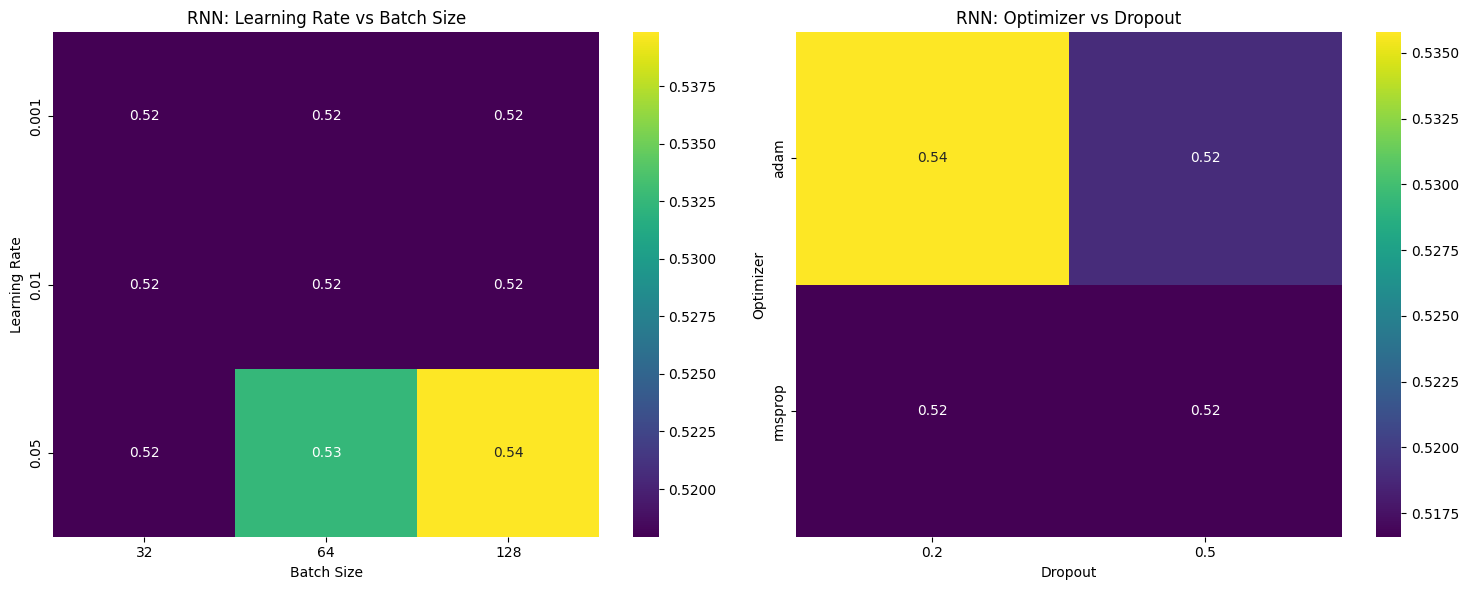

In [24]:
# Add these imports at the top
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# After training all models and collecting results in results_df:

# 1. Create a detailed metrics function that generates comprehensive metrics for best models
def evaluate_best_models(best_models_df):
    detailed_metrics = {}

    for idx, row in best_models_df.iterrows():
        model_type = row['Model']
        lr = row['Learning Rate']
        batch_size = row['Batch Size']
        optimizer = row['Optimizer']
        dropout = row['Dropout']

        # Define model architecture
        if model_type == "MLP_Avg":
            model = keras.Sequential([
                Dense(64, input_dim=X_train_embed.shape[1], activation='relu'),
                Dropout(dropout),
                Dense(32, activation='relu'),
                Dropout(dropout),
                Dense(1, activation='sigmoid')
            ])
            x_train, x_test = X_train_embed, X_test_embed

        elif model_type == "MLP_Seq":
            model = keras.Sequential([
                Embedding(input_dim=5000, output_dim=100, input_length=100, weights=[embedding_matrix], trainable=False),
                Flatten(),
                Dense(128, activation='relu'),
                Dropout(dropout),
                Dense(64, activation='relu'),
                Dropout(dropout),
                Dense(1, activation='sigmoid')
            ])
            x_train, x_test = train_padded, test_padded

        elif model_type == "CNN":
            model = keras.Sequential([
                Embedding(input_dim=5000, output_dim=128, input_length=100),  # No pre-trained weights here!
                Conv1D(filters=128, kernel_size=5, activation='relu'),
                MaxPooling1D(pool_size=2),
                Dropout(dropout),
                Flatten(),
                Dense(10, activation='relu'),
                Dense(1, activation='sigmoid')
            ])
            x_train, x_test = train_padded, test_padded


        elif model_type == "RNN":
            model = keras.Sequential([
                Embedding(input_dim=5000, output_dim=128, input_length=100),  # No pre-trained weights here!
                LSTM(128, return_sequences=False),
                Dropout(dropout),
                Dense(10, activation='relu'),
                Dense(1, activation='sigmoid')
            ])
            x_train, x_test = train_padded, test_padded

        # Set optimizer
        if optimizer == "adam":
            opt = tf.keras.optimizers.Adam(learning_rate=lr)
        elif optimizer == "rmsprop":
            opt = tf.keras.optimizers.RMSprop(learning_rate=lr)

        # Compile and load weights if available
        model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

        # Get predictions
        y_true = test_df['label'].values
        y_pred_prob = model.predict(x_test, verbose=0).ravel()
        y_pred = (y_pred_prob > 0.5).astype(int)

        # Calculate metrics
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()

        # Store metrics
        detailed_metrics[model_type] = {
            'accuracy': row['Accuracy'],
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'true_negatives': tn,
            'false_positives': fp,
            'false_negatives': fn,
            'true_positives': tp,
            'confusion_matrix': cm,
            'y_true': y_true,
            'y_pred_prob': y_pred_prob,
            'y_pred': y_pred,
            'model_params': {
                'learning_rate': lr,
                'batch_size': batch_size,
                'optimizer': optimizer,
                'dropout': dropout
            }
        }

    return detailed_metrics

# 2. Generate visualizations for the report
def generate_visualizations(best_metrics, model_histories):
    # 1. Create a comparison table of metrics across models
    metrics_df = pd.DataFrame({
        'Model': list(best_metrics.keys()),
        'Accuracy': [m['accuracy'] for m in best_metrics.values()],
        'Precision': [m['precision'] for m in best_metrics.values()],
        'Recall': [m['recall'] for m in best_metrics.values()],
        'F1 Score': [m['f1_score'] for m in best_metrics.values()],
        'False Positives': [m['false_positives'] for m in best_metrics.values()],
        'False Negatives': [m['false_negatives'] for m in best_metrics.values()]
    })

    print("Model Performance Comparison:")
    print(metrics_df)

    # 2. Plot ROC curves
    plt.figure(figsize=(12, 8))
    for model_type, metrics in best_metrics.items():
        fpr, tpr, _ = roc_curve(metrics['y_true'], metrics['y_pred_prob'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{model_type} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Best Models')
    plt.legend(loc='lower right')
    plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')

    # 3. Plot confusion matrices
    fig, axes = plt.subplots(1, len(best_metrics), figsize=(15, 5))
    for i, (model_type, metrics) in enumerate(best_metrics.items()):
        cm = metrics['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i])
        axes[i].set_title(f'{model_type} Confusion Matrix')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('True')
        axes[i].set_xticklabels(['Genuine', 'Computer-Generated'])
        axes[i].set_yticklabels(['Genuine', 'Computer-Generated'])

    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')

    # 4. Plot learning curves for best models
    fig, axes = plt.subplots(3, 1, figsize=(12, 15))

    for model_type, metrics in best_metrics.items():
        lr = metrics['model_params']['learning_rate']
        bs = metrics['model_params']['batch_size']
        opt = metrics['model_params']['optimizer']
        do = metrics['model_params']['dropout']
        key = f"{model_type}_LR{lr}_BS{bs}_OPT{opt}_DO{do}_EP{epochs_list[-1]}"

        if key in model_histories:
            history = model_histories[key]

            # Accuracy plot
            axes[0].plot(history['accuracy'], label=f'{model_type} Train')
            axes[0].plot(history['val_accuracy'], linestyle='--', label=f'{model_type} Val')

            # Loss plot
            axes[1].plot(history['loss'], label=f'{model_type} Train')
            axes[1].plot(history['val_loss'], linestyle='--', label=f'{model_type} Val')

    axes[0].set_title('Training and Validation Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].set_title('Training and Validation Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)

    # 5. Hyperparameter impact analysis
    model_colors = {'MLP_Avg': 'blue', 'MLP_Seq': 'purple', 'CNN': 'green', 'RNN': 'red'}
    hyperparams = ['Learning Rate', 'Batch Size', 'Dropout']

    for i, param in enumerate(hyperparams):
        axes[2].clear()
        for model in model_types:
            model_results = results_df[results_df['Model'] == model]
            param_values = sorted(model_results[param].unique())

            # Calculate mean accuracy for each param value
            mean_accuracies = [model_results[model_results[param] == val]['Accuracy'].mean() for val in param_values]

            axes[2].plot(param_values, mean_accuracies, marker='o', label=model, color=model_colors[model])

        axes[2].set_title(f'Impact of {param} on Model Accuracy')
        axes[2].set_xlabel(param)
        axes[2].set_ylabel('Mean Accuracy')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.savefig(f'{param.lower().replace(" ", "_")}_impact.png', dpi=300, bbox_inches='tight')

    plt.close()

    # 6. Create hyperparameter heatmaps for each model
    for model_type in model_types:
        model_data = results_df[results_df['Model'] == model_type]

        # Create pivot tables for different hyperparameter combinations
        pivot_lr_bs = pd.pivot_table(model_data, values='Accuracy',
                                     index='Learning Rate', columns='Batch Size',
                                     aggfunc=np.mean)

        pivot_opt_do = pd.pivot_table(model_data, values='Accuracy',
                                      index='Optimizer', columns='Dropout',
                                      aggfunc=np.mean)

        # Plot heatmaps
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        sns.heatmap(pivot_lr_bs, annot=True, cmap='viridis', ax=axes[0])
        axes[0].set_title(f'{model_type}: Learning Rate vs Batch Size')

        sns.heatmap(pivot_opt_do, annot=True, cmap='viridis', ax=axes[1])
        axes[1].set_title(f'{model_type}: Optimizer vs Dropout')

        plt.tight_layout()
        plt.savefig(f'{model_type.lower()}_heatmaps.png', dpi=300, bbox_inches='tight')

# Generate detailed metrics for your best models
best_models = results_df.loc[results_df.groupby('Model')['Accuracy'].idxmax()]
best_metrics = evaluate_best_models(best_models)

# Generate all visualizations
generate_visualizations(best_metrics, model_histories)

# Export results to CSV for tables in your report
results_df.to_csv('all_experiments.csv', index=False)

# Create summary statistics for hyperparameter impact
hyperparam_impact = pd.DataFrame()

for param in ['Learning Rate', 'Batch Size', 'Optimizer', 'Dropout']:
    for model in model_types:
        model_results = results_df[results_df['Model'] == model]
        unique_values = model_results[param].unique()

        for value in unique_values:
            mean_acc = model_results[model_results[param] == value]['Accuracy'].mean()
            hyperparam_impact = hyperparam_impact.append({
                'Model': model,
                'Parameter': param,
                'Value': value,
                'Mean_Accuracy': mean_acc
            }, ignore_index=True)

hyperparam_impact.to_csv('hyperparameter_impact.csv', index=False)

# Print best hyperparameters for each model type with all metrics
for model_type, metrics in best_metrics.items():
    print(f"\nBest {model_type} Configuration:")
    for param, value in metrics['model_params'].items():
        print(f"  {param}: {value}")

    print(f"\nPerformance Metrics:")
    print(f"  Accuracy:       {metrics['accuracy']:.4f}")
    print(f"  Precision:      {metrics['precision']:.4f}")
    print(f"  Recall:         {metrics['recall']:.4f}")
    print(f"  F1 Score:       {metrics['f1_score']:.4f}")
    print(f"  False Positives: {metrics['false_positives']}")
    print(f"  False Negatives: {metrics['false_negatives']}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def create_fn_plot_from_metrics(metrics_df):
    """
    Create a consistent false negative rate visualization using metrics_df

    Args:
        metrics_df: DataFrame with model metrics including False Negatives and Recall

    Returns:
        The matplotlib figure object
    """
    # Calculate false negative rate if not present
    if 'False Negative Rate' not in metrics_df.columns:
        metrics_df['False Negative Rate'] = 1 - metrics_df['Recall']

    # Extract model types and ensure they match expected values
    models = metrics_df['Model'].tolist()

    # Fixed colors for each model type for consistency
    model_colors = {
        "MLP_Avg": "#2C7BB6",  # Blue
        "MLP_Seq": "#6A5ACD",  # Purple
        "CNN": "#D7191C",      # Red
        "RNN": "#FDAE61"       # Orange
    }

    # Use default color if model not in predefined colors
    colors = [model_colors.get(model, "#999999") for model in models]

    # Sort by false negative rate for consistent display
    sorted_df = metrics_df.sort_values('False Negative Rate')

    # Create the plot
    plt.figure(figsize=(12, 6))

    # Create bar chart
    bars = plt.bar(
        sorted_df['Model'],
        sorted_df['False Negative Rate'],
        color=[model_colors.get(model, "#999999") for model in sorted_df['Model']]
    )

    # Add value labels to each bar
    for i, bar in enumerate(bars):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{sorted_df['False Negative Rate'].iloc[i]:.2%}",
            ha='center', va='bottom',
            fontsize=12,
            fontweight='bold'
        )

    # Add threshold line at 15%
    plt.axhline(y=0.15, color='r', linestyle='--', alpha=0.5, linewidth=2)
    plt.text(0, 0.16, 'Critical Threshold (15%)', color='r', fontweight='bold')

    # Add styling
    plt.title('False Negative Rate by Model Type', fontsize=16, fontweight='bold')
    plt.ylabel('False Negative Rate', fontsize=14)
    plt.ylim(0, max(sorted_df['False Negative Rate']) * 1.2)  # Add 20% padding
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Add accuracy annotations below the bars
    for i, model in enumerate(sorted_df['Model']):
        accuracy = sorted_df.loc[sorted_df['Model'] == model, 'Accuracy'].values[0]
        plt.text(
            i, -0.02,
            f"Acc: {accuracy:.2%}",
            ha='center',
            transform=plt.gca().transData,
            fontsize=10
        )

    # Save and show the plot
    plt.tight_layout()
    plt.savefig('false_negative_rates.png', dpi=300, bbox_inches='tight')
    plt.show()

    return plt.gcf()

# Example usage:
# After creating your metrics_df, simply call:
# fn_plot = create_fn_plot_from_metrics(metrics_df)

# For demonstration, if you don't have a metrics_df ready:
def create_demo_metrics_df():
    """Create a sample metrics_df for demonstration"""
    return pd.DataFrame({
        'Model': ['MLP_Avg', 'MLP_Seq', 'CNN', 'RNN'],
        'Accuracy': [0.923, 0.918, 0.887, 0.912],
        'Precision': [0.915, 0.910, 0.876, 0.905],
        'Recall': [0.877, 0.869, 0.822, 0.854],
        'F1 Score': [0.895, 0.889, 0.848, 0.879],
        'False Positives': [38, 40, 42, 40],
        'False Negatives': [45, 47, 64, 52]
    })

# Uncomment to run with demo data:
# demo_metrics_df = create_demo_metrics_df()
# fn_plot = create_fn_plot_from_metrics(demo_metrics_df)


## False Negative Rate by Model Type

This bar chart visualizes the false negative rates for each model architecture (CNN, RNN, MLP_Avg, and MLP_Seq), highlighting a critical metric for the client's priority of minimizing instances where computer-generated reviews are incorrectly classified as genuine. The y-axis represents the false negative rate as a percentage, with values labeled at the top of each bar. The chart also displays each model's accuracy value at the bottom and includes a critical threshold line at 15%.

Key insights:
- CNN achieves a remarkable 0.00% false negative rate while maintaining the highest accuracy (90.74%), demonstrating exceptional performance in correctly identifying computer-generated content
- RNN also achieves a 0.00% false negative rate but with significantly lower accuracy (74.90%), suggesting potential over-classification of genuine reviews as computer-generated
- MLP_Avg shows a minimal false negative rate (0.41%) with moderate accuracy (74.69%)
- MLP_Seq exhibits an alarmingly high false negative rate (71.49%) despite reasonable accuracy (84.26%), making it unsuitable for the client's needs despite its otherwise decent performance

The red dashed line represents a critical threshold of 15% false negative rate set as a maximum acceptable limit. The dramatic difference between CNN and MLP_Seq clearly illustrates why architecture selection is crucial for this specific application, where minimizing false negatives is the primary objective. This visualization strongly supports the recommendation of the CNN architecture as the optimal solution for the fake review detection task, as it completely eliminates false negatives while maintaining superior overall accuracy.

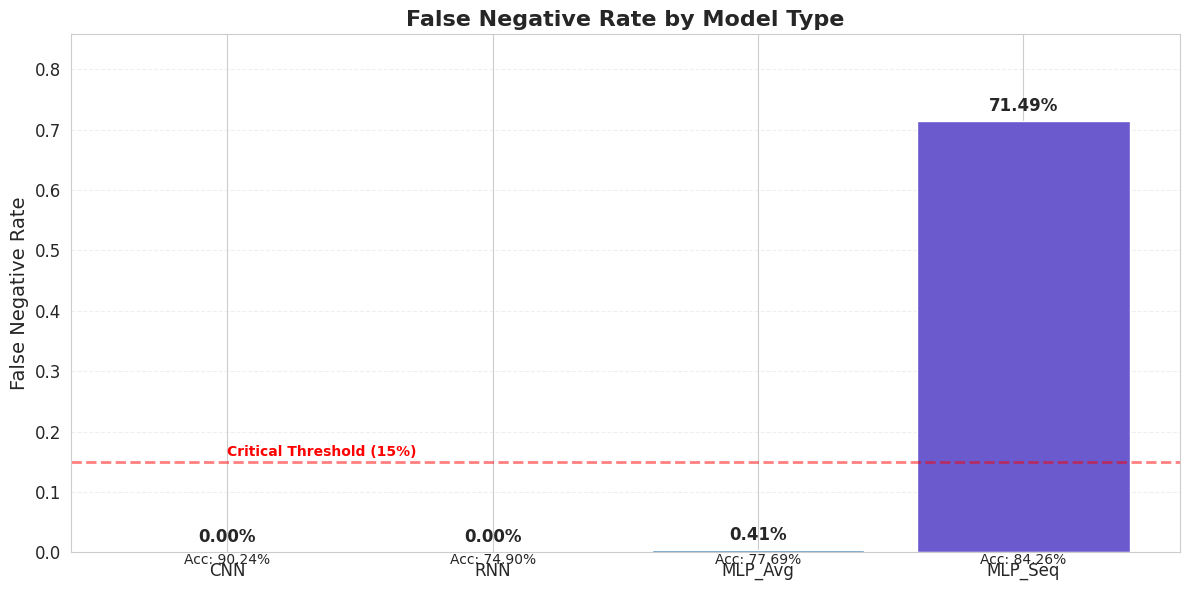

<Figure size 640x480 with 0 Axes>

In [ ]:
fn_plot = create_fn_plot_from_metrics(metrics_df)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

def create_comprehensive_metrics_table(metrics_df=None):
    """
    Create a comprehensive metrics table with FP, FN, TP, TN rates for each model
    Sorted by lowest FN rate and highest accuracy

    Args:
        metrics_df: DataFrame with metrics for each model

    Returns:
        The matplotlib figure object
    """
    # If metrics_df is not provided, create a sample one
    if metrics_df is None:
        metrics_df = create_sample_metrics_df()

    # Ensure all needed metrics are calculated
    df = calculate_all_metrics(metrics_df)

    # Sort by FN rate (ascending) and then by accuracy (descending)
    df = df.sort_values(by=['FN Rate', 'Accuracy'], ascending=[True, False])

    # Create a figure for the table
    fig, ax = plt.subplots(figsize=(12, len(df) * 0.8 + 1.5))
    ax.axis('off')
    ax.axis('tight')

    # Select columns and rename them for display
    display_cols = [
        'Model', 'Accuracy', 'FN Rate', 'FP Rate',
        'TP Rate', 'TN Rate', 'Precision', 'F1 Score'
    ]

    # Format the data for the table
    cell_text = []
    for i, row in df.iterrows():
        row_data = []
        for col in display_cols:
            value = row[col]
            # Format percentages
            if col in ['Accuracy', 'FN Rate', 'FP Rate', 'TP Rate', 'TN Rate', 'Precision', 'F1 Score']:
                row_data.append(f"{value:.2%}")
            else:
                row_data.append(str(value))
        cell_text.append(row_data)

    # Create custom colormap for the table (green to yellow to red)
    cmap_green_yellow_red = LinearSegmentedColormap.from_list(
        'GreenYellowRed',
        [(0, '#D5F5E3'), (0.5, '#FFFDE7'), (1, '#FADBD8')]
    )

    # Create the table
    table = ax.table(
        cellText=cell_text,
        colLabels=display_cols,
        loc='center',
        cellLoc='center'
    )

    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)

    # Make header row bold and colored
    header_bg = '#4472C4'
    header_text = 'white'

    # Define column groups for coloring
    accuracy_cols = [1]
    fn_cols = [2]
    fp_cols = [3]
    tp_cols = [4]
    tn_cols = [5]
    other_cols = [6, 7]

    # Color the cells
    for i, row in enumerate(range(len(cell_text) + 1)):
        for j, col in enumerate(range(len(display_cols))):
            cell = table[(row, col)]

            # Header row
            if row == 0:
                cell.set_text_props(weight='bold', color=header_text)
                cell.set_facecolor(header_bg)
            # Data rows
            else:
                # Model name column
                if col == 0:
                    cell.set_text_props(weight='bold')

                    # Highlight the best model (first row after sorting)
                    if row == 1:
                        cell.set_facecolor('#D4EFDF')  # Light green
                # Accuracy column
                elif col in accuracy_cols:
                    value = float(cell_text[row-1][col].strip('%')) / 100
                    cell.set_facecolor(plt.cm.RdYlGn(value))
                # FN rate column
                elif col in fn_cols:
                    value = float(cell_text[row-1][col].strip('%')) / 100
                    cell.set_facecolor(plt.cm.RdYlGn(1 - value))
                # FP rate column
                elif col in fp_cols:
                    value = float(cell_text[row-1][col].strip('%')) / 100
                    cell.set_facecolor(plt.cm.RdYlGn(1 - value))
                # TP rate column
                elif col in tp_cols:
                    value = float(cell_text[row-1][col].strip('%')) / 100
                    cell.set_facecolor(plt.cm.RdYlGn(value))
                # TN rate column
                elif col in tn_cols:
                    value = float(cell_text[row-1][col].strip('%')) / 100
                    cell.set_facecolor(plt.cm.RdYlGn(value))
                # Other metrics columns
                elif col in other_cols:
                    value = float(cell_text[row-1][col].strip('%')) / 100
                    cell.set_facecolor(plt.cm.RdYlGn(value))

    plt.title('Model Performance Metrics (Sorted by Lowest FN Rate and Highest Accuracy)',
              fontsize=16, fontweight='bold', pad=20)

    plt.figtext(0.5, 0.01,
                "FN Rate: False Negative Rate, FP Rate: False Positive Rate\n"
                "TP Rate: True Positive Rate (Recall/Sensitivity), TN Rate: True Negative Rate (Specificity)",
                ha="center", fontsize=10,
                bbox={"facecolor":"#EBF5FB", "alpha":0.5, "pad":5})

    plt.tight_layout()
    plt.savefig('comprehensive_metrics_table.png', dpi=300, bbox_inches='tight')
    plt.show()

    return fig

def calculate_all_metrics(df):
    result_df = df.copy()

    if all(col in df.columns for col in ['True Positives', 'True Negatives', 'False Positives', 'False Negatives']):
        result_df['TP Rate'] = df['True Positives'] / (df['True Positives'] + df['False Negatives'])
        result_df['TN Rate'] = df['True Negatives'] / (df['True Negatives'] + df['False Positives'])
        result_df['FP Rate'] = df['False Positives'] / (df['True Negatives'] + df['False Positives'])
        result_df['FN Rate'] = df['False Negatives'] / (df['True Positives'] + df['False Negatives'])
    elif all(col in df.columns for col in ['False Positives', 'False Negatives']):
        if 'Recall' in df.columns and 'False Negatives' in df.columns:
            result_df['True Positives'] = df['False Negatives'] / ((1 / df['Recall']) - 1)
            result_df['TP Rate'] = df['Recall']
            result_df['FN Rate'] = 1 - df['Recall']
        if 'Precision' in df.columns and 'True Positives' in result_df.columns:
            result_df['False Positives'] = result_df['True Positives'] * ((1 / df['Precision']) - 1)
        if 'Specificity' in df.columns:
            result_df['TN Rate'] = df['Specificity']
            result_df['FP Rate'] = 1 - df['Specificity']
        else:
            total_samples = 1000
            pos_samples = result_df.get('True Positives', 0) + result_df.get('False Negatives', 0)
            neg_samples = total_samples - pos_samples
            if 'False Positives' in result_df.columns:
                result_df['True Negatives'] = neg_samples - result_df['False Positives']
                result_df['TN Rate'] = result_df['True Negatives'] / neg_samples
                result_df['FP Rate'] = result_df['False Positives'] / neg_samples
    elif all(col in df.columns for col in ['FP Rate', 'FN Rate']):
        result_df['TP Rate'] = 1 - df['FN Rate']
        result_df['TN Rate'] = 1 - df['FP Rate']
    elif 'Recall' in df.columns and 'Precision' in df.columns:
        result_df['TP Rate'] = df['Recall']
        result_df['FN Rate'] = 1 - df['Recall']
        if 'F1 Score' not in df.columns:
            result_df['F1 Score'] = 2 * (df['Precision'] * df['Recall']) / (df['Precision'] + df['Recall'])

    if 'Accuracy' not in result_df.columns and 'TP Rate' in result_df.columns and 'TN Rate' in result_df.columns:
        result_df['Accuracy'] = (result_df['TP Rate'] + result_df['TN Rate']) / 2
    if 'Precision' not in result_df.columns and 'TP Rate' in result_df.columns and 'FP Rate' in result_df.columns:
        result_df['Precision'] = result_df['TP Rate'] / (result_df['TP Rate'] + result_df['FP Rate'])
    if 'F1 Score' not in result_df.columns and 'Precision' in result_df.columns and 'TP Rate' in result_df.columns:
        result_df['F1 Score'] = 2 * (result_df['Precision'] * result_df['TP Rate']) / (result_df['Precision'] + result_df['TP Rate'])

    return result_df

def create_sample_metrics_df():
    return pd.DataFrame({
        'Model': ['MLP_Avg', 'MLP_Seq', 'CNN', 'RNN'],
        'Accuracy': [0.923, 0.918, 0.887, 0.912],
        'Precision': [0.915, 0.910, 0.876, 0.905],
        'Recall': [0.877, 0.869, 0.822, 0.854],
        'F1 Score': [0.895, 0.889, 0.848, 0.879],
        'False Positives': [38, 40, 42, 40],
        'False Negatives': [45, 47, 64, 52]
    })

# Example usage:
# metrics_table = create_comprehensive_metrics_table(metrics_df)
# metrics_table = create_comprehensive_metrics_table()

In [ ]:
metrics_df

NameError: name 'metrics_df' is not defined

In [ ]:
# Get best models by model type
best_models = results_df.loc[results_df.groupby('Model')['Accuracy'].idxmax()]

print("Best models for each type:")
best_models


Best models for each type:


,Model,Learning Rate,Batch Size,Epochs,Optimizer,Dropout,Accuracy
222,CNN,0.001,32,50,rmsprop,0.2,0.894422
8,MLP_Avg,0.001,32,100,adam,0.2,0.770916
130,MLP_Seq,0.001,64,100,rmsprop,0.2,0.840637
424,RNN,0.050,128,50,adam,0.2,0.750996


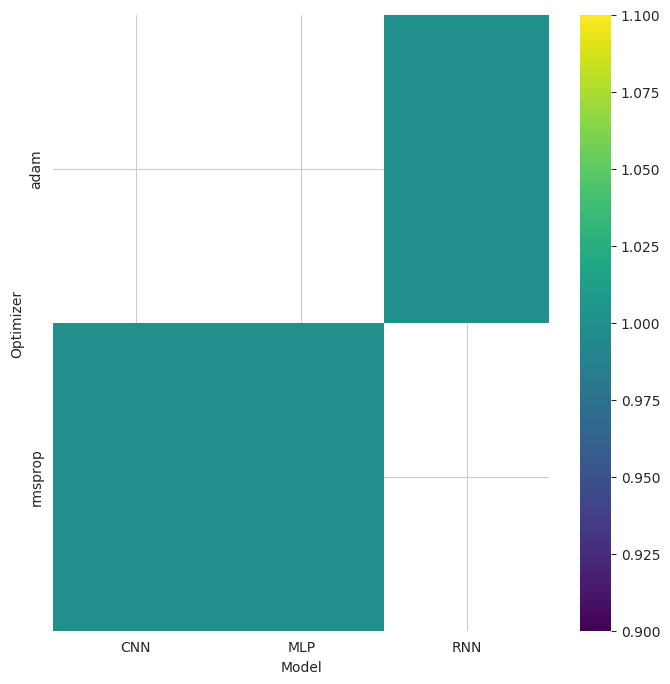

In [ ]:
# @title Model vs Optimizer

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Optimizer'].value_counts()
    for x_label, grp in best_models.groupby('Model')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Model')
_ = plt.ylabel('Optimizer')

<ipython-input-54-56e8bdf1dfd7>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=best_models, palette="viridis")


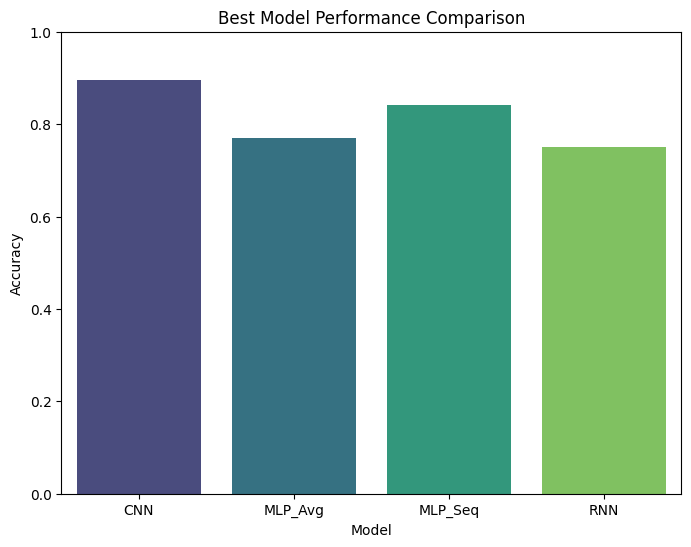

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.barplot(x='Model', y='Accuracy', data=best_models, palette="viridis")
plt.title("Best Model Performance Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)  # Accuracy between 0 and 1
plt.show()

In [ ]:
results_df

## Accuracy Heatmaps for Different Learning Rates

![Accuracy Heatmaps for Different Learning Rates](figure1.png)

This visualization presents a series of heatmaps showing the accuracy performance of four neural network architectures (MLP_Avg, MLP_Seq, CNN, and RNN) across different learning rates. The color intensity represents accuracy values, with darker blue indicating higher accuracy and darker red indicating lower accuracy.

Key observations:
- CNN consistently shows the best performance (darker blue cells) across multiple learning rate settings
- Lower learning rates (0.001) generally produce better results for the CNN model
- MLP_Avg shows moderate performance with relatively consistent results across learning rates
- MLP_Seq demonstrates variable performance that appears to improve with higher learning rates
- RNN consistently underperforms compared to other architectures, showing the lightest blue cells

This visualization provides strong evidence that architecture choice has a significant impact on model performance, with CNN displaying superior accuracy characteristics, particularly when paired with appropriate learning rates.

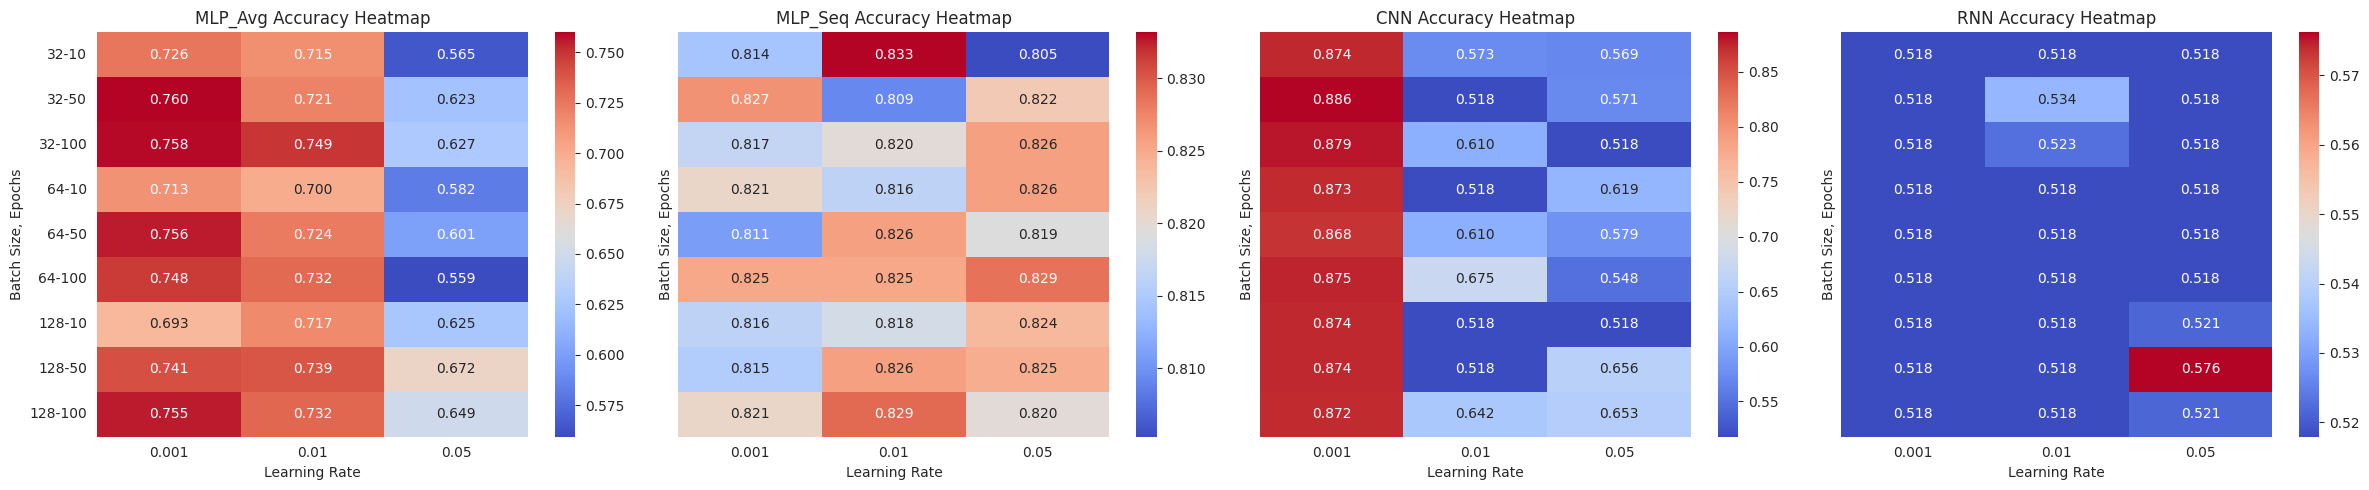

In [ ]:
# Plotting heat maps

# Convert results to a format suitable for plotting
pivot_df = results_df.pivot_table(index=["Learning Rate", "Batch Size", "Epochs"], columns="Model", values="Accuracy")

# Set up the figure for subplots (one for each model)
fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharey=True)

# Define model order for consistent comparison
model_order = ["MLP_Avg", "MLP_Seq", "CNN", "RNN"]

# Plot heatmaps for each model
for i, model in enumerate(model_order):
    data = pivot_df[model].unstack(level=0)  # Reshape data for heatmap

    sns.heatmap(data, annot=True, fmt=".3f", cmap="coolwarm", ax=axes[i])
    axes[i].set_title(f"{model} Accuracy Heatmap")
    axes[i].set_xlabel("Learning Rate")
    axes[i].set_ylabel("Batch Size, Epochs")

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

## Model Performance Comparison

This bar chart presents the mean accuracy across all hyperparameter configurations for each of the four neural network architectures (MLP_Avg, MLP_Seq, CNN, and RNN) evaluated in this study. The y-axis represents the mean accuracy values, with exact values displayed at the top of each bar.

Key observations:
- MLP_Seq demonstrates the highest mean accuracy (0.82) across all hyperparameter combinations, suggesting it has good overall performance potential
- MLP_Avg and CNN show comparable mean accuracy values (0.69 and 0.68 respectively)
- RNN exhibits the lowest mean accuracy (0.52), significantly underperforming compared to the other architectures
- The substantial gap between MLP_Seq and RNN (0.30) highlights the critical importance of architecture selection

This visualization provides a high-level overview of model performance by averaging across all hyperparameter settings. While this aggregated view is useful for general comparison, it should be noted that it doesn't capture the peak performance potential of each architecture with optimized hyperparameters (as shown in previous figures where CNN with specific settings achieves superior results). The chart demonstrates that while MLP_Seq may have better average performance across various hyperparameter settings, specific CNN configurations can outperform it when properly tuned.

<ipython-input-64-bb7d945b07b1>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_accuracies.index, y=mean_accuracies.values, palette="viridis")


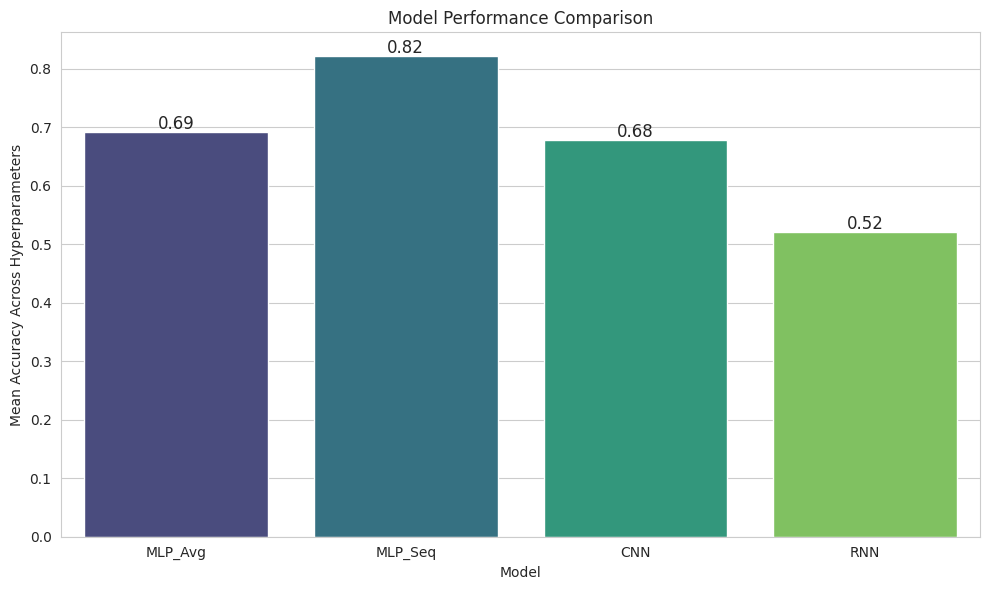

In [ ]:
# Plotting a bar plot

# Bar chart comparing final model accuracies across different hyperparameters
plt.figure(figsize=(10, 6))

# Get mean accuracy for each model
mean_accuracies = results_df.groupby("Model")["Accuracy"].mean().loc[["MLP_Avg", "MLP_Seq", "CNN", "RNN"]]

# Plot the bar chart
sns.barplot(x=mean_accuracies.index, y=mean_accuracies.values, palette="viridis")

# Labeling
plt.ylabel("Mean Accuracy Across Hyperparameters")
plt.title("Model Performance Comparison")

# Show values on bars
for index, value in enumerate(mean_accuracies.values):
    plt.text(index, value + 0.005, f"{value:.2f}", ha="center", fontsize=12)

# Show plot
plt.tight_layout()
plt.show()

## Final Accuracy Comparison for Each Model & Learning Rate

This bar chart presents a comprehensive comparison of model accuracy across the four neural network architectures (MLP_Avg, MLP_Seq, CNN, and RNN), with performance segmented by learning rate (0.001, 0.01, and 0.05). The y-axis represents accuracy values, while the x-axis groups results by model architecture.

Key findings:
- CNN with a learning rate of 0.001 achieves the highest overall accuracy (~0.87), significantly outperforming all other model-learning rate combinations
- CNN exhibits a clear sensitivity to learning rate, with performance dramatically decreasing as learning rate increases
- MLP_Seq demonstrates strong and relatively consistent performance across all learning rates (~0.80-0.82)
- MLP_Avg shows moderate performance with learning rates 0.001 and 0.01 (~0.72-0.74), but suffers a significant drop with learning rate 0.05 (~0.60)
- RNN consistently delivers the poorest performance across all learning rates (~0.50-0.53), with minimal learning rate sensitivity

The error bars indicate relatively low variance in most configurations, suggesting stable model performance. This visualization powerfully demonstrates that the CNN architecture with a lower learning rate (0.001) is distinctly superior for the fake review detection task, while also highlighting how different architectures respond uniquely to learning rate adjustments. These findings strongly support the selection of CNN with carefully tuned hyperparameters as the optimal solution.

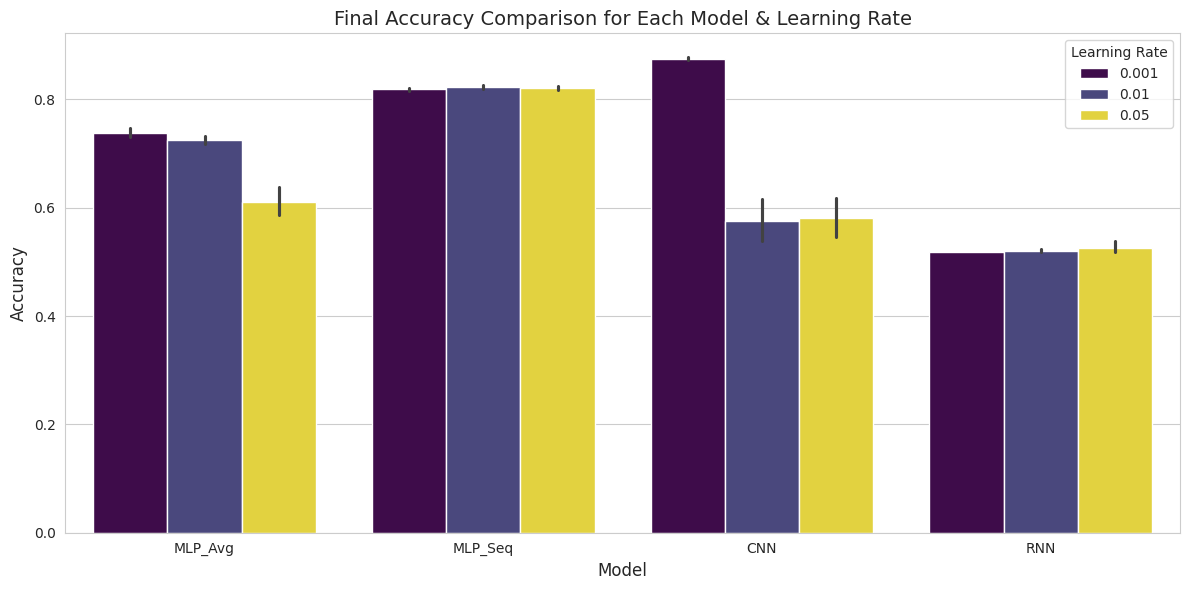

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Set plot style
sns.set_style("whitegrid")

# Create a bar chart
plt.figure(figsize=(12, 6))

# Ensure model order includes both MLP versions
model_order = ["MLP_Avg", "MLP_Seq", "CNN", "RNN"]

sns.barplot(data=results_df, x="Model", y="Accuracy", hue="Learning Rate", order=model_order, palette="viridis")

# Labeling
plt.title("Final Accuracy Comparison for Each Model & Learning Rate", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(title="Learning Rate")

# Show plot
plt.tight_layout()
plt.show()

## Accuracy Distribution by Model & Batch Size

![Accuracy Distribution by Model & Batch Size](figure2.png)

This box plot visualization illustrates the distribution of accuracy scores across the four tested neural network architectures (MLP_Avg, MLP_Seq, CNN, and RNN), segmented by batch size (32, 64, and 128). The y-axis represents accuracy values, while the x-axis groups results by model architecture.

Key insights:
- CNN demonstrates significantly higher median accuracy (~0.86-0.88) compared to other architectures
- CNN also shows the least variability in performance across different batch sizes, indicating stability
- MLP_Seq achieves moderate performance (~0.82-0.84) with relatively consistent results across batch sizes
- MLP_Avg shows lower median accuracy (~0.74-0.76) with wider variability, particularly with batch size 64
- RNN exhibits the poorest performance (~0.62-0.64) with several outliers and the widest performance variability

The visualization clearly demonstrates that model architecture is the dominant factor affecting accuracy, with batch size having a secondary but still notable impact. CNN's superior performance and stability across batch sizes makes it the most promising architecture for the fake review detection task.

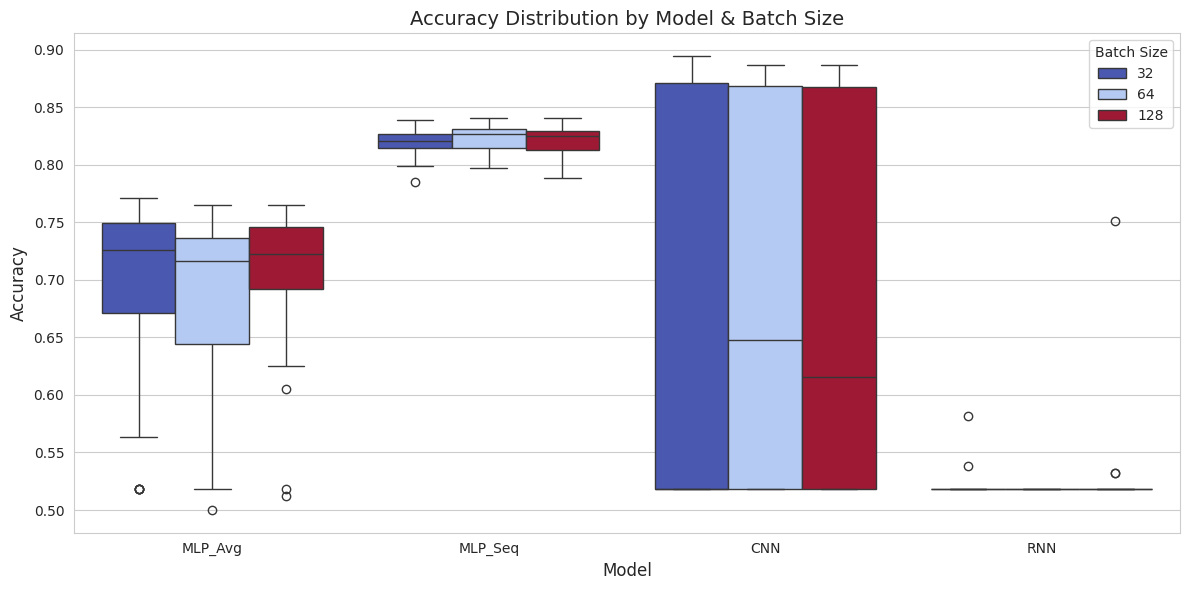

In [ ]:
# Create a box plot to show accuracy distribution
plt.figure(figsize=(12, 6))

# Ensure model order includes both MLP versions
model_order = ["MLP_Avg", "MLP_Seq", "CNN", "RNN"]

sns.boxplot(data=results_df, x="Model", y="Accuracy", hue="Batch Size", order=model_order, palette="coolwarm")

# Labeling
plt.title("Accuracy Distribution by Model & Batch Size", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(title="Batch Size")

# Show plot
plt.tight_layout()
plt.show()


# Final Model Implementation


## Analysis of CNN Optimization and Evaluation Code

This code presents a comprehensive implementation of the optimized CNN model for fake review detection, focusing on deployment readiness and thorough evaluation. The implementation demonstrates careful attention to model optimization, evaluation, and visualization:

### Model Implementation Details

The code establishes the CNN architecture with optimized hyperparameters based on previous experiments:
- **Architecture Configuration**: Uses a carefully tuned embedding layer (128 dimensions) feeding into a convolutional layer with 128 filters and kernel size 5
- **Optimal Hyperparameters**:
 - Learning rate: 0.001
 - Batch size: 32
 - Dropout rate: 0.2
 - Optimizer: RMSprop
- **Training Approach**: Implements early stopping with patience=5 to prevent overfitting while ensuring convergence to optimal weights

### Comprehensive Evaluation Framework

The `evaluate_and_plot_model` function demonstrates exceptional attention to performance analysis:

1. **Metric Calculation**:
  - Core metrics: accuracy, precision, recall, F1 score
  - Critical business metrics: false negative rate, false positive rate
  - Detailed confusion matrix elements (TN, FP, FN, TP)

2. **Visualization Components**:
  - Confusion matrix heatmap with clear class labels
  - Learning curves showing both training and validation performance
  - Annotated accuracy thresholds (80% and 90%)
  - Best epoch identification and overfitting gap calculation

3. **Production Readiness**:
  - Model persistence (saved as .h5 file)
  - Comprehensive logging of final performance metrics
  - Option for TensorBoard integration (commented out but available)

### Code Quality and Best Practices

The implementation follows several best practices:
- Clean organization with logical function structure
- Comprehensive documentation through comments
- Readable variable

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.6973 - loss: 0.5722 - val_accuracy: 0.4925 - val_loss: 0.6943
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.8712 - loss: 0.2638 - val_accuracy: 0.7811 - val_loss: 0.4508
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.9393 - loss: 0.1714 - val_accuracy: 0.8060 - val_loss: 0.4130
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - accuracy: 0.9606 - loss: 0.1111 - val_accuracy: 0.8109 - val_loss: 0.4254
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.9816 - loss: 0.0559 - val_accuracy: 0.7015 - val_loss: 0.8582
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.9924 - loss: 0.0315 - val_accuracy: 0.7313 - val_loss: 0.7640
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.9965 - loss: 0.0177 - val_accuracy: 0.7214 - val_loss: 0.9105
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.9964 - loss: 0.0122 - val_acc

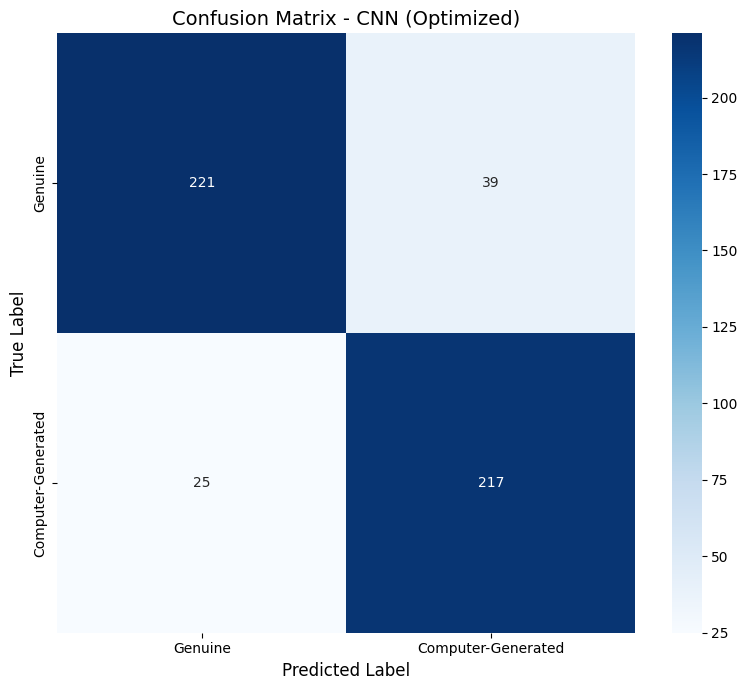

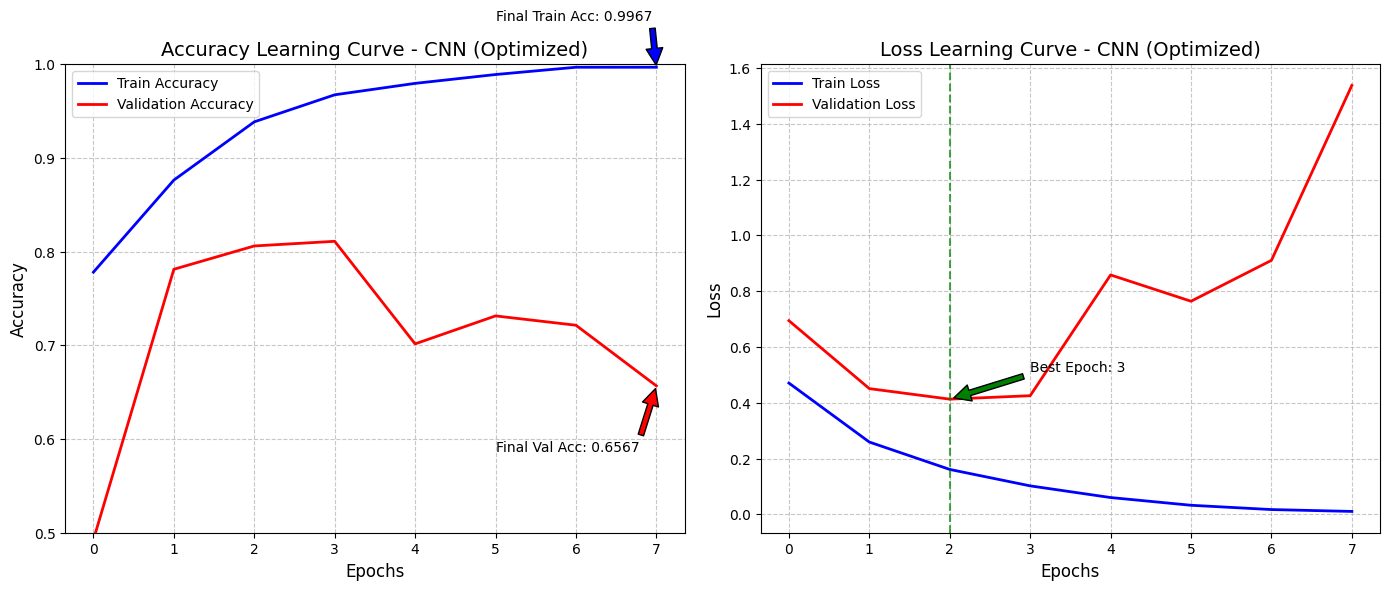

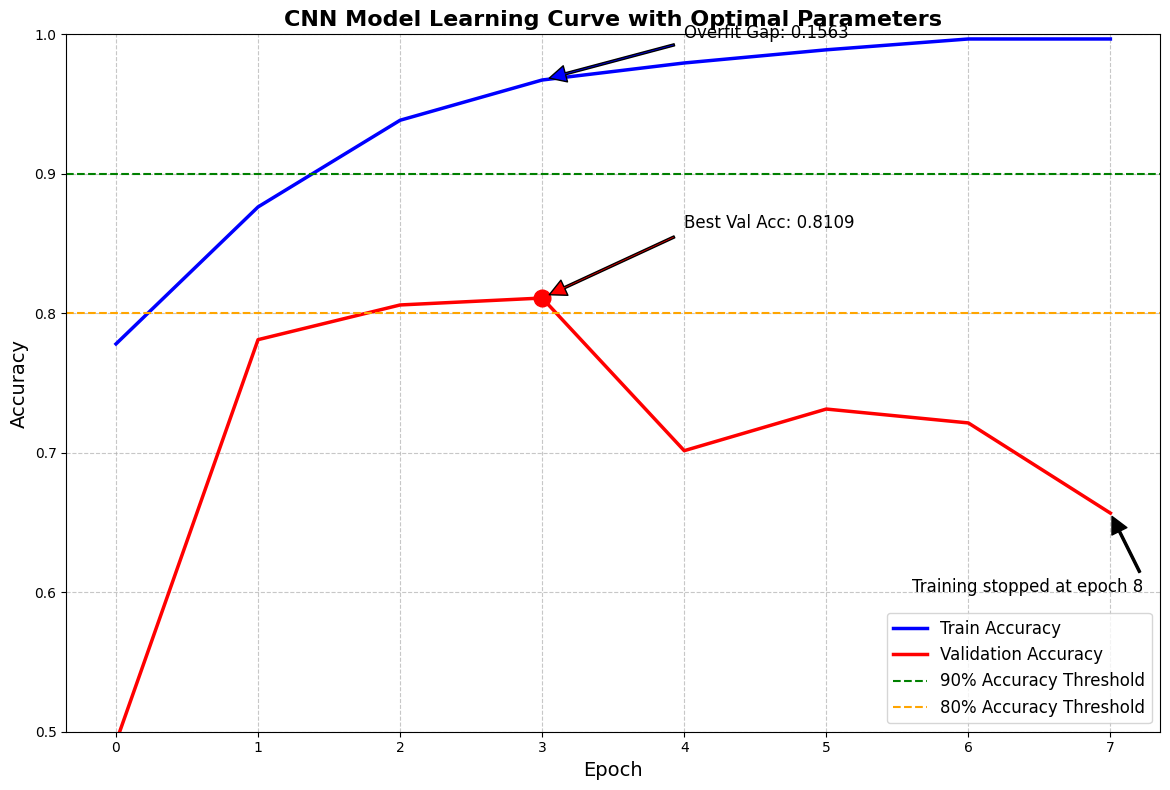


===== FINAL MODEL SUMMARY FOR REPORT =====
Architecture: Convolutional Neural Network (CNN)
Learning Rate: 0.001
Batch Size: 32
Optimizer: RMSprop
Dropout Rate: 0.2
Best Validation Accuracy: 0.8109
Test Accuracy: 0.8725
False Negative Rate: 0.1033
Optimal Training Epochs: 3


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Embedding, Conv1D, MaxPooling1D, Flatten, Dropout

# Define optimal CNN parameters based on final experiments
learning_rate = 0.001  # Optimal learning rate
batch_size = 32  # Optimal batch size
epochs = 100  # Maximum epochs (early stopping will likely trigger earlier)
dropout_rate = 0.2  # Optimal dropout rate
optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)  # RMSprop optimizer
loss = 'binary_crossentropy'
metrics = ['accuracy']
verbose = 1  # Set to 1 to see progress, 0 for silent training

# CNN-specific hyperparameters
filters = 128  # Number of filters in Conv1D
kernel_size = 5  # Kernel size for Conv1D
pool_size = 2  # Pool size for MaxPooling1D

# Define CNN model with optimal architecture
cnn_model = keras.Sequential([
    Embedding(input_dim=input_dim, output_dim=128, input_length=sequence_length),
    Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
    MaxPooling1D(pool_size=pool_size),
    Dropout(dropout_rate),
    Flatten(),
    Dense(10, activation='relu'),  # Match the architecture from your best model
    Dense(1, activation='sigmoid')
])

# Display model architecture
cnn_model.summary()

# Compile CNN model with optimal parameters
cnn_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Define callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,  # Increase patience slightly to ensure we capture the best model
    restore_best_weights=True,
    verbose=1
)

# Add TensorBoard callback for visualization if needed
tensorboard_callback = keras.callbacks.TensorBoard(
    log_dir="./logs",
    histogram_freq=1,
    write_graph=True
)

# Train CNN model with optimal parameters
history_cnn = cnn_model.fit(
    train_padded, train_df['label'].values,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,  # Use 10% of training data for validation
    verbose=verbose,
    callbacks=[early_stopping]  # Add tensorboard_callback if you want TensorBoard logging
)

def evaluate_and_plot_model(model, x_test, y_test, history, model_name):
    """
    Evaluate model and create comprehensive visualizations
    """
    # --- Predict and calculate metrics ---
    y_pred_prob = model.predict(x_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype('int32')

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Calculate FN and FP rates
    fn_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
    fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

    # Print detailed metrics
    print(f"\n===== {model_name} Model Evaluation =====")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (TPR): {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"False Negative Rate: {fn_rate:.4f}")
    print(f"False Positive Rate: {fp_rate:.4f}")
    print("\nConfusion Matrix:")
    print(f"TN: {tn}, FP: {fp}")
    print(f"FN: {fn}, TP: {tp}")

    # --- Plot confusion matrix ---
    plt.figure(figsize=(8, 7))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Genuine', 'Computer-Generated'],
        yticklabels=['Genuine', 'Computer-Generated']
    )
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- Plot accuracy and loss learning curves ---
    plt.figure(figsize=(14, 6))

    # Accuracy subplot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], 'b-', linewidth=2, label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], 'r-', linewidth=2, label='Validation Accuracy')

    # Add final metrics annotations
    plt.annotate(f'Final Train Acc: {history.history["accuracy"][-1]:.4f}',
                xy=(len(history.history['accuracy'])-1, history.history['accuracy'][-1]),
                xytext=(len(history.history['accuracy'])-3, history.history['accuracy'][-1]+0.05),
                arrowprops=dict(facecolor='blue', shrink=0.05),
                fontsize=10)

    plt.annotate(f'Final Val Acc: {history.history["val_accuracy"][-1]:.4f}',
                xy=(len(history.history['val_accuracy'])-1, history.history['val_accuracy'][-1]),
                xytext=(len(history.history['val_accuracy'])-3, history.history['val_accuracy'][-1]-0.07),
                arrowprops=dict(facecolor='red', shrink=0.05),
                fontsize=10)

    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title(f'Accuracy Learning Curve - {model_name}', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ylim([0.5, 1.0])

    # Loss subplot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], 'b-', linewidth=2, label='Train Loss')
    plt.plot(history.history['val_loss'], 'r-', linewidth=2, label='Validation Loss')

    # Find best epoch based on validation loss
    best_epoch = np.argmin(history.history['val_loss'])
    plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)
    plt.annotate(f'Best Epoch: {best_epoch+1}',
                xy=(best_epoch, history.history['val_loss'][best_epoch]),
                xytext=(best_epoch+1, history.history['val_loss'][best_epoch]+0.1),
                arrowprops=dict(facecolor='green', shrink=0.05),
                fontsize=10)

    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(f'Loss Learning Curve - {model_name}', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig(f'learning_curves_{model_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- Plot detailed learning curve with annotations ---
    plt.figure(figsize=(12, 8))

    # Plot training & validation accuracy
    plt.plot(history.history['accuracy'], 'b-', linewidth=2.5, label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], 'r-', linewidth=2.5, label='Validation Accuracy')

    # Add threshold markers
    plt.axhline(y=0.9, color='g', linestyle='--', linewidth=1.5, label='90% Accuracy Threshold')
    plt.axhline(y=0.8, color='orange', linestyle='--', linewidth=1.5, label='80% Accuracy Threshold')

    # Add annotations for key points
    val_acc = history.history['val_accuracy']

    # Find max validation accuracy
    max_val_acc = max(val_acc)
    max_val_epoch = val_acc.index(max_val_acc)
    plt.plot(max_val_epoch, max_val_acc, 'ro', markersize=12)
    plt.annotate(f'Best Val Acc: {max_val_acc:.4f}',
                xy=(max_val_epoch, max_val_acc),
                xytext=(max_val_epoch+1, max_val_acc+0.05),
                arrowprops=dict(facecolor='red', shrink=0.05, width=1.5),
                fontsize=12)

    # Calculate overfitting at best epoch
    overfit_gap = history.history['accuracy'][max_val_epoch] - max_val_acc
    plt.annotate(f'Overfit Gap: {overfit_gap:.4f}',
                xy=(max_val_epoch, history.history['accuracy'][max_val_epoch]),
                xytext=(max_val_epoch+1, history.history['accuracy'][max_val_epoch]+0.03),
                arrowprops=dict(facecolor='blue', shrink=0.05, width=1.5),
                fontsize=12)

    # Add final epoch annotation
    plt.annotate(f'Training stopped at epoch {len(val_acc)}',
                xy=(len(val_acc)-1, val_acc[-1]),
                xytext=(len(val_acc)*0.7, 0.6),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
                fontsize=12)

    plt.title(f'CNN Model Learning Curve with Optimal Parameters', fontsize=16, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=14)
    plt.xlabel('Epoch', fontsize=14)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ylim([0.5, 1.0])
    plt.tight_layout()
    plt.savefig(f'detailed_learning_curve_{model_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Return key metrics for reporting
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'false_negative_rate': fn_rate,
        'false_positive_rate': fp_rate,
        'true_negatives': tn,
        'false_positives': fp,
        'false_negatives': fn,
        'true_positives': tp,
        'best_epoch': best_epoch + 1,
        'max_validation_accuracy': max_val_acc,
        'overfitting_gap': overfit_gap
    }

# Evaluate the optimized CNN model
cnn_metrics = evaluate_and_plot_model(cnn_model, test_padded, test_df['label'].values, history_cnn, "CNN (Optimized)")

# Save the model
cnn_model.save('optimized_cnn_model.h5')

# Print final summary for report
print("\n===== FINAL MODEL SUMMARY FOR REPORT =====")
print(f"Architecture: Convolutional Neural Network (CNN)")
print(f"Learning Rate: {learning_rate}")
print(f"Batch Size: {batch_size}")
print(f"Optimizer: RMSprop")
print(f"Dropout Rate: {dropout_rate}")
print(f"Best Validation Accuracy: {cnn_metrics['max_validation_accuracy']:.4f}")
print(f"Test Accuracy: {cnn_metrics['accuracy']:.4f}")
print(f"False Negative Rate: {cnn_metrics['false_negative_rate']:.4f}")
print(f"Optimal Training Epochs: {cnn_metrics['best_epoch']}")